In [ ]:
# Installation
!pip install torch torchvision
!pip install opencv-python scikit-image matplotlib numpy Pillow
!pip install pycocotools

In [ ]:
import os
!git clone https://github.com/ia-project-parasite/IA-PROJECT-PARASITE-REPO.git
os.chdir('IA-PROJECT-PARASITE-REPO')

Cloning into 'IA-PROJECT-PARASITE-REPO'...
remote: Enumerating objects: 431, done.
remote: Counting objects: 100% (86/86), done.
remote: Compressing objects: 100% (70/70), done.
remote: Total 431 (delta 20), reused 77 (delta 16), pack-reused 345 (from 1)
Receiving objects: 100% (431/431), 730.61 MiB | 17.54 MiB/s, done.
Resolving deltas: 100% (139/139), done.
Updating files: 100% (206/206), done.


In [ ]:
import torch
import torchvision
from torchvision.models.detection import maskrcnn_resnet50_fpn_v2
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
from pathlib import Path
from tqdm import tqdm
import json
from skimage.measure import label as sk_label, regionprops
from scipy.ndimage import label as ndimage_label
from skimage.morphology import remove_small_holes, remove_small_objects
import matplotlib.patches as patches
from collections import defaultdict
import random
import shutil
import albumentations as A
import pandas as pd

# Dataset

In [ ]:
def apply_clahe_and_brightness(bgr):
    """Apply CLAHE + brightness boost."""
    img_lab = cv2.cvtColor(bgr, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(img_lab)
    clahe = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8, 8))
    l2 = clahe.apply(l)
    img_lab = cv2.merge((l2, a, b))
    bgr_corr = cv2.cvtColor(img_lab, cv2.COLOR_LAB2BGR)
    hsv = cv2.cvtColor(bgr_corr, cv2.COLOR_BGR2HSV)
    h, s, v = cv2.split(hsv)
    v = cv2.add(v, 15)
    hsv = cv2.merge([h, s, v])
    return cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)


def specimen_mask(bgr, use_hull=False):
    """Generate binary mask for specimen."""
    hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)
    H, S, V = cv2.split(hsv)
    ret, _ = cv2.threshold(V, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    v_thr, s_thr = int(max(ret * 0.7, 25)), 15
    m = ((V >= v_thr) & (S >= s_thr)).astype(np.uint8)
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    m = cv2.morphologyEx(m, cv2.MORPH_OPEN, k)
    m = cv2.morphologyEx(m, cv2.MORPH_CLOSE, k)
    m = remove_small_objects(m.astype(bool), min_size=3000)
    m = remove_small_holes(m, area_threshold=50000).astype(np.uint8)
    n, lab = cv2.connectedComponents(m)
    if n <= 1:
        return np.zeros(m.shape, bool)
    cnts = np.bincount(lab.ravel())[1:]
    keep = 1 + np.argmax(cnts)
    m = (lab == keep).astype(np.uint8)
    if use_hull:
        contours, _ = cv2.findContours(m, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if contours:
            hull = cv2.convexHull(np.vstack(contours))
            m_hull = np.zeros_like(m)
            cv2.drawContours(m_hull, [hull], -1, 1, -1)
            m = m_hull
    return m.astype(bool)


def roi_from_mask(img, mask, pad=10):
    """Extract ROI bounding box."""
    ys, xs = np.where(mask)
    if len(ys) == 0 or len(xs) == 0:
        return None, None, None
    y0, y1 = max(0, ys.min() - pad), min(img.shape[0], ys.max() + pad)
    x0, x1 = max(0, xs.min() - pad), min(img.shape[1], xs.max() + pad)
    return (y0, y1, x0, x1), img[y0:y1, x0:x1], mask[y0:y1, x0:x1]


def get_white_points_from_label(label_img):
    """Extract white pixel coordinates from label image."""
    if len(label_img.shape) == 3:
        gray = cv2.cvtColor(label_img, cv2.COLOR_BGR2GRAY)
    else:
        gray = label_img
    _, thresh = cv2.threshold(gray, 200, 255, cv2.THRESH_BINARY)
    ys, xs = np.where(thresh > 0)
    return [(int(x), int(y)) for x, y in zip(xs, ys)] if len(xs) > 0 else []


def extract_centroids_from_points(points, img_shape):
    """Convert dense point cloud to centroids."""
    if len(points) == 0:
        return []
    binary_mask = np.zeros(img_shape[:2], dtype=np.uint8)
    for x, y in points:
        if 0 <= y < img_shape[0] and 0 <= x < img_shape[1]:
            binary_mask[y, x] = 255
    labeled_mask, num_parasites = ndimage_label(binary_mask)
    centroids = []
    for region_id in range(1, num_parasites + 1):
        ys, xs = np.where(labeled_mask == region_id)
        if len(ys) > 0:
            centroids.append((int(xs.mean()), int(ys.mean())))
    return centroids


# =============================================================================
# 2. FIXED INSTANCE MASK CREATION
# =============================================================================

def create_instance_mask_from_centroids_fixed(tile_mask, points_local, search_radius=10):
    """
    FIXED: Convert binary mask to instance mask using centroids.

    Key improvements:
    1. Tracks which blobs have been assigned to avoid overwriting
    2. Searches nearby pixels if centroid doesn't land on mask
    3. Returns diagnostic info for debugging
    """
    stats = {
        'total_centroids': len(points_local),
        'direct_hits': 0,
        'nearby_hits': 0,
        'missed': 0,
        'duplicate_blob': 0
    }

    if tile_mask is None or len(points_local) == 0:
        return None, stats

    binary_mask = (tile_mask > 0).astype(np.uint8)
    labeled_mask, num_objects = ndimage_label(binary_mask)
    instance_mask = np.zeros_like(labeled_mask, dtype=np.int32)
    used_blobs = set()
    instance_id = 1

    for (x, y) in points_local:
        if not (0 <= y < labeled_mask.shape[0] and 0 <= x < labeled_mask.shape[1]):
            stats['missed'] += 1
            continue

        blob_id = labeled_mask[y, x]

        if blob_id > 0:
            stats['direct_hits'] += 1
        else:
            # Search nearby pixels in expanding squares
            found = False
            for radius in range(1, search_radius + 1):
                for dy in range(-radius, radius + 1):
                    for dx in range(-radius, radius + 1):
                        if abs(dy) != radius and abs(dx) != radius:
                            continue
                        ny, nx = y + dy, x + dx
                        if 0 <= ny < labeled_mask.shape[0] and 0 <= nx < labeled_mask.shape[1]:
                            if labeled_mask[ny, nx] > 0:
                                blob_id = labeled_mask[ny, nx]
                                found = True
                                break
                    if found:
                        break
                if found:
                    stats['nearby_hits'] += 1
                    break
            if not found:
                stats['missed'] += 1
                continue

        if blob_id in used_blobs:
            stats['duplicate_blob'] += 1
            continue

        instance_mask[labeled_mask == blob_id] = instance_id
        used_blobs.add(blob_id)
        instance_id += 1

    return instance_mask, stats


def get_instances_from_mask(instance_mask, min_area=5):
    """Extract individual instance masks and bounding boxes."""
    if instance_mask is None:
        return [], []

    masks, boxes = [], []
    unique_ids = np.unique(instance_mask)
    unique_ids = unique_ids[unique_ids > 0]

    for inst_id in unique_ids:
        mask = (instance_mask == inst_id).astype(np.uint8)
        area = mask.sum()
        if area < min_area:
            continue

        pos = np.where(mask)
        if len(pos[0]) == 0:
            continue

        y_min, y_max = pos[0].min(), pos[0].max()
        x_min, x_max = pos[1].min(), pos[1].max()

        # FIXED: Ensure non-degenerate boxes
        if x_max <= x_min:
            x_max = x_min + 1
        if y_max <= y_min:
            y_max = y_min + 1

        masks.append(mask)
        boxes.append([x_min, y_min, x_max, y_max])

    return masks, boxes


# =============================================================================
# 3. TILE GENERATION
# =============================================================================

def split_images_fixed_grid(original_img, label_img, mask_img, points, tile_size=1024):
    """Split images into fixed tile_size grid."""
    height, width = original_img.shape[:2]
    tiles = []
    tile_count = 0
    total_stats = {'direct_hits': 0, 'nearby_hits': 0, 'missed': 0, 'duplicate_blob': 0}

    for y in range(0, height, tile_size):
        for x in range(0, width, tile_size):
            x1, y1 = x, y
            x2, y2 = min(x + tile_size, width), min(y + tile_size, height)

            tile_original = original_img[y1:y2, x1:x2]
            tile_label = label_img[y1:y2, x1:x2]
            tile_mask = mask_img[y1:y2, x1:x2] if mask_img is not None else None

            actual_h, actual_w = tile_original.shape[:2]
            if actual_h < tile_size or actual_w < tile_size:
                padded_original = np.zeros((tile_size, tile_size, 3), dtype=np.uint8)
                padded_original[:actual_h, :actual_w] = tile_original

                if len(tile_label.shape) == 3:
                    padded_label = np.zeros((tile_size, tile_size, 3), dtype=np.uint8)
                else:
                    padded_label = np.zeros((tile_size, tile_size), dtype=np.uint8)
                padded_label[:actual_h, :actual_w] = tile_label

                padded_mask = None
                if tile_mask is not None:
                    padded_mask = np.zeros((tile_size, tile_size), dtype=np.uint8)
                    padded_mask[:actual_h, :actual_w] = tile_mask

                tile_original, tile_label, tile_mask = padded_original, padded_label, padded_mask

            if tile_original.mean() < 5:
                continue

            tile_points = [(px - x1, py - y1) for px, py in points if x1 <= px < x2 and y1 <= py < y2]

            instance_mask = None
            if len(tile_points) > 0 and tile_mask is not None:
                instance_mask, stats = create_instance_mask_from_centroids_fixed(tile_mask, tile_points)
                for key in total_stats:
                    total_stats[key] += stats.get(key, 0)

            tiles.append({
                'tile_original': tile_original,
                'tile_label': tile_label,
                'tile_mask': tile_mask,
                'instance_mask': instance_mask,
                'points_local': tile_points,
                'tile_id': f"tile_{tile_count:04d}",
                'global_bbox': (x1, y1, x2, y2),
                'num_parasites': len(tile_points),
                'is_negative': len(tile_points) == 0
            })
            tile_count += 1

    return tiles, total_stats


def process_image_complete(image_path, label_path, mask_path, image_id, tile_size=1024, apply_clahe=True, extract_roi=True):
    """Complete preprocessing pipeline."""
    img = cv2.imread(image_path)
    label = cv2.imread(label_path)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE) if mask_path and os.path.exists(mask_path) else None

    if img is None or label is None:
        print(f"Warning: Could not read {image_id}")
        return [], {}

    original_shape = img.shape
    if apply_clahe:
        img = apply_clahe_and_brightness(img)

    roi_bbox = None
    if extract_roi:
        specimen_m = specimen_mask(img, use_hull=False)
        bbox, img_roi, mask_roi = roi_from_mask(img, specimen_m, pad=10)
        if bbox is None:
            img_roi, label_roi, mask_roi_img = img, label, mask
        else:
            y0, y1, x0, x1 = bbox
            roi_bbox = bbox
            img_roi = img_roi.copy()
            img_roi[~mask_roi] = 0
            label_roi = label[y0:y1, x0:x1]
            mask_roi_img = mask[y0:y1, x0:x1] if mask is not None else None
    else:
        img_roi, label_roi, mask_roi_img = img, label, mask

    points = get_white_points_from_label(label_roi)
    if len(points) == 0:
        return [], {}

    centroids = extract_centroids_from_points(points, label_roi.shape)
    print(f"  [{image_id}] {len(points)} pixels -> {len(centroids)} centroids")

    if len(centroids) == 0:
        return [], {}

    tiles, stats = split_images_fixed_grid(img_roi, label_roi, mask_roi_img, centroids, tile_size=tile_size)

    for tile in tiles:
        tile['image_id'] = f"{image_id}_{tile['tile_id']}"
        tile['base_image_id'] = image_id
        tile['original_shape'] = original_shape
        tile['roi_bbox'] = roi_bbox

    return tiles, stats

In [ ]:
def create_instance_mask_from_centroids(tile_mask, points_local):
    """
    Convert binary mask to instance mask using centroids.
    Each parasite gets a unique ID.

    Args:
        tile_mask: Binary mask (0=background, 255=parasite)
        points_local: List of (x, y) centroid coordinates

    Returns:
        instance_mask: Integer array where each parasite has unique ID
    """
    if tile_mask is None or len(points_local) == 0:
        return None

    # Convert to binary
    binary_mask = (tile_mask > 0).astype(np.uint8)

    # Label connected components
    labeled_mask, num_objects = ndimage_label(binary_mask)

    # Create instance mask with unique IDs
    instance_mask = np.zeros_like(labeled_mask, dtype=np.int32)

    # Assign each centroid to its corresponding blob
    for idx, (x, y) in enumerate(points_local, start=1):
        # Get the label at this centroid position
        if 0 <= y < labeled_mask.shape[0] and 0 <= x < labeled_mask.shape[1]:
            blob_id = labeled_mask[y, x]
            if blob_id > 0:  # Valid blob
                instance_mask[labeled_mask == blob_id] = idx

    return instance_mask


def split_images_fixed_grid(original_img, label_img, mask_img, points,
                            tile_size=1024, roi_bbox=None):
    """
    Split images into FIXED tile_size grid and keep ALL meaningful tiles:
    - Keep parasite tiles (positive samples)
    - Keep negative tiles (specimen/intestine without parasites)
    - Remove ONLY empty tiles (pure black/background with no content)

    Args:
        original_img: Original preprocessed image
        label_img: Label image with white points
        mask_img: Binary mask (optional)
        points: List of parasite centroids
        tile_size: Fixed tile size (default 1024)
        roi_bbox: ROI bounding box (optional)

    Returns:
        List of tile dictionaries
    """

    height, width = original_img.shape[:2]
    tiles = []
    tile_count = 0

    for y in range(0, height, tile_size):
        for x in range(0, width, tile_size):

            # Crop box
            box = (x, y, min(x + tile_size, width), min(y + tile_size, height))
            x1, y1, x2, y2 = box

            tile_original = original_img[y1:y2, x1:x2]
            tile_label    = label_img[y1:y2, x1:x2]
            tile_mask     = mask_img[y1:y2, x1:x2] if mask_img is not None else None

            # Pad edge tiles to fixed size
            actual_h, actual_w = tile_original.shape[:2]
            if actual_h < tile_size or actual_w < tile_size:

                # Pad original
                padded_original = np.zeros((tile_size, tile_size, 3), dtype=np.uint8)
                padded_original[:actual_h, :actual_w] = tile_original

                # Pad label
                if len(tile_label.shape) == 3:
                    padded_label = np.zeros((tile_size, tile_size, 3), dtype=np.uint8)
                else:
                    padded_label = np.zeros((tile_size, tile_size), dtype=np.uint8)
                padded_label[:actual_h, :actual_w] = tile_label

                # Pad mask
                if tile_mask is not None:
                    padded_mask = np.zeros((tile_size, tile_size), dtype=np.uint8)
                    padded_mask[:actual_h, :actual_w] = tile_mask
                else:
                    padded_mask = None

                tile_original = padded_original
                tile_label = padded_label
                tile_mask = padded_mask

            # --- MODIFIED: Remove ONLY completely empty tiles (pure black background) ---
            # Check if tile is completely empty (mean intensity very low)
            # This removes tiles that are pure black padding/background
            # Threshold of 5 allows for very dark but non-empty regions
            if tile_original.mean() < 5:
                continue  # Skip completely empty tile

            # Collect parasite points inside this tile
            tile_points = []
            for px, py in points:
                if x1 <= px < x2 and y1 <= py < y2:
                    tile_points.append((px - x1, py - y1))

            # Generate instance mask ONLY if parasites are present
            # For negative tiles (no parasites), instance_mask will be None
            instance_mask = None
            if len(tile_points) > 0:
                instance_mask = create_instance_mask_from_centroids(tile_mask, tile_points)
            # If len(tile_points) == 0, this is a negative tile (no parasites)
            # We still keep it because it contains specimen content

            # Save tile (both positive and negative tiles are kept)
            tiles.append({
                'tile_original': tile_original,
                'tile_label': tile_label,
                'tile_mask': tile_mask,
                'instance_mask': instance_mask,
                'points_local': tile_points,
                'tile_id': f"tile_{tile_count:04d}",
                'global_bbox': (x1, y1, x2, y2),
                'num_parasites': len(tile_points),  # 0 for negative tiles
                'is_negative': len(tile_points) == 0  # Flag to identify negative tiles
            })

            tile_count += 1

    return tiles

def process_image_complete(image_path, label_path, mask_path, image_id,
                          tile_size=1024, apply_clahe=True, extract_roi=True):
    """
    Complete preprocessing pipeline with instance mask generation:
    1. Load images (original + label + mask if available)
    2. Apply CLAHE + brightness boost
    3. Extract ROI (specimen)
    4. Extract and convert points to centroids
    5. Split into fixed-size tiles
    6. Generate instance masks (unique ID per parasite)

    Args:
        image_path: Path to original image
        label_path: Path to label image (white dots)
        mask_path: Path to mask image (can be None)
        image_id: Image identifier
        tile_size: Fixed tile size (default 1024)
        apply_clahe: Apply CLAHE preprocessing
        extract_roi: Extract specimen ROI

    Returns:
        List of tile dictionaries with instance masks
    """
    # Load images
    img = cv2.imread(image_path)
    label = cv2.imread(label_path)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE) if mask_path and os.path.exists(mask_path) else None

    if img is None or label is None:
        print(f"Warning: Could not read {image_id}")
        return []

    original_shape = img.shape

    # Apply preprocessing
    if apply_clahe:
        img = apply_clahe_and_brightness(img)

    # Extract ROI
    roi_bbox = None
    if extract_roi:
        specimen_m = specimen_mask(img, use_hull=False)
        bbox, img_roi, mask_roi = roi_from_mask(img, specimen_m, pad=10)

        if bbox is None:
            print(f"Warning: Could not extract ROI for {image_id}")
            img_roi = img
            label_roi = label
            mask_roi_img = mask
        else:
            y0, y1, x0, x1 = bbox
            roi_bbox = bbox

            # Black out background
            img_roi = img_roi.copy()
            img_roi[~mask_roi] = 0

            # Crop label and mask
            label_roi = label[y0:y1, x0:x1]
            mask_roi_img = mask[y0:y1, x0:x1] if mask is not None else None
    else:
        img_roi = img
        label_roi = label
        mask_roi_img = mask

    # Extract points from label
    points = get_white_points_from_label(label_roi)
    if len(points) == 0:
        print(f"Warning: No points found in {image_id}")
        return []

    # Convert to centroids
    centroids = extract_centroids_from_points(points, label_roi.shape)
    print(f"  [{image_id}] {len(points)} pixels → {len(centroids)} centroids")

    if len(centroids) == 0:
        print(f"Warning: No centroids extracted for {image_id}")
        return []

    # Split into tiles with instance masks
    tiles = split_images_fixed_grid(
        img_roi, label_roi, mask_roi_img, centroids,
        tile_size=tile_size, roi_bbox=roi_bbox
    )

    # Add metadata
    for tile in tiles:
        tile['image_id'] = f"{image_id}_{tile['tile_id']}"
        tile['base_image_id'] = image_id
        tile['original_shape'] = original_shape
        tile['roi_bbox'] = roi_bbox

    return tiles

In [ ]:
museum_labels_dir = "Museum labels"
output_dir = "Combined_Dataset"
TILE_SIZE = 1024

os.makedirs(output_dir, exist_ok=True)

# Find all folders
folders = [f for f in os.listdir(museum_labels_dir)
           if os.path.isdir(os.path.join(museum_labels_dir, f))]

all_tiles = []
tiles_per_image = {}

# Process each image
for folder in tqdm(folders, desc="Processing images"):
    folder_path = os.path.join(museum_labels_dir, folder)

    # Look for files
    raw_img_path = os.path.join(folder_path, f"{folder}.JPG")
    label_mask_path = os.path.join(folder_path, f"{folder}_labels.png")
    mask_path = os.path.join(folder_path, f"{folder}_mask.png")  # Ground truth mask

    if not os.path.exists(label_mask_path):
        label_mask_path = os.path.join(folder_path, f"{folder}_labels.JPG")

    if not os.path.exists(raw_img_path) or not os.path.exists(label_mask_path):
        continue

    # Process with complete pipeline
    tiles = process_image_complete(
        raw_img_path,
        label_mask_path,
        mask_path if os.path.exists(mask_path) else None,
        folder,
        tile_size=TILE_SIZE,
        apply_clahe=True,
        extract_roi=True
    )

    if len(tiles) == 0:
        continue

    # Create folder structure
    image_output_dir = os.path.join(output_dir, folder)
    tiles_dir = os.path.join(image_output_dir, "tiles")
    labels_dir = os.path.join(image_output_dir, "labels")
    masks_dir = os.path.join(image_output_dir, "masks")
    annotations_dir = os.path.join(image_output_dir, "annotations")

    os.makedirs(tiles_dir, exist_ok=True)
    os.makedirs(labels_dir, exist_ok=True)
    os.makedirs(masks_dir, exist_ok=True)
    os.makedirs(annotations_dir, exist_ok=True)

    # Save each tile
    for tile in tiles:
        tile_id = tile['tile_id']
        is_negative = tile['is_negative']

        # Save original tile
        tile_img_path = os.path.join(tiles_dir, f"{tile_id}.png")
        cv2.imwrite(tile_img_path, tile['tile_original'])

        # Save label tile
        label_img_path = os.path.join(labels_dir, f"{tile_id}.png")
        cv2.imwrite(label_img_path, tile['tile_label'])

        # Save binary mask (255 for all parasites)
        # For negative tiles, this might be None or empty
        if tile['tile_mask'] is not None:
            mask_img_path = os.path.join(masks_dir, f"{tile_id}_binary.png")
            cv2.imwrite(mask_img_path, tile['tile_mask'])
        else:
            # Create empty mask for negative tiles
            empty_mask = np.zeros((TILE_SIZE, TILE_SIZE), dtype=np.uint8)
            mask_img_path = os.path.join(masks_dir, f"{tile_id}_binary.png")
            cv2.imwrite(mask_img_path, empty_mask)

        # Save instance mask (.npy with unique IDs per parasite)
        if tile['instance_mask'] is not None:
            # Positive tile - has parasites
            instance_mask_path = os.path.join(masks_dir, f"{tile_id}_instance.npy")
            np.save(instance_mask_path, tile['instance_mask'])

            # Also save as PNG for visualization
            instance_vis = (tile['instance_mask'] > 0).astype(np.uint8) * 255
            cv2.imwrite(os.path.join(masks_dir, f"{tile_id}_instance.png"), instance_vis)
        else:
            # Negative tile - no parasites
            # Save empty instance mask
            empty_instance = np.zeros((TILE_SIZE, TILE_SIZE), dtype=np.int32)
            instance_mask_path = os.path.join(masks_dir, f"{tile_id}_instance.npy")
            np.save(instance_mask_path, empty_instance)

            # Save empty visualization
            empty_vis = np.zeros((TILE_SIZE, TILE_SIZE), dtype=np.uint8)
            cv2.imwrite(os.path.join(masks_dir, f"{tile_id}_instance.png"), empty_vis)

        # Save annotations (points + bboxes)
        x1_global, y1_global, x2_global, y2_global = tile['global_bbox']

        # For negative tiles, these will be empty lists
        points_local = [[int(x), int(y)] for x, y in tile['points_local']]
        points_global = [[int(x + x1_global), int(y + y1_global)] for x, y in tile['points_local']]

        # Generate bounding boxes
        box_size = 40
        bboxes_local = []
        for x, y in tile['points_local']:
            x1 = max(0, int(x - box_size // 2))
            y1 = max(0, int(y - box_size // 2))
            x2 = min(TILE_SIZE, int(x + box_size // 2))
            y2 = min(TILE_SIZE, int(y + box_size // 2))
            bboxes_local.append([x1, y1, x2, y2])

        annotation_data = {
            'tile_id': tile['image_id'],
            'base_image_id': tile['base_image_id'],
            'num_parasites': tile['num_parasites'],  # 0 for negative tiles
            'is_negative': is_negative,  # Flag for negative tiles
            'centroids_local': points_local,  # Empty for negative tiles
            'centroids_global': points_global,  # Empty for negative tiles
            'bboxes_local': bboxes_local,  # Empty for negative tiles
            'box_size': box_size,
            'tile_bbox': [int(x1_global), int(y1_global), int(x2_global), int(y2_global)],
            'original_shape': [int(d) for d in tile['original_shape']],
            'roi_bbox': [int(d) for d in tile['roi_bbox']] if tile['roi_bbox'] else None
        }

        annotation_path = os.path.join(annotations_dir, f"{tile_id}.json")
        with open(annotation_path, 'w') as f:
            json.dump(annotation_data, f, indent=2)

    all_tiles.extend(tiles)
    tiles_per_image[folder] = len(tiles)

# Enhanced statistics
positive_tiles = [t for t in all_tiles if t['num_parasites'] > 0]
negative_tiles = [t for t in all_tiles if t['num_parasites'] == 0]

print(f"\n{'='*80}")
print(f"Processing Complete!")
print(f"{'='*80}")
print(f"Total tiles created: {len(all_tiles)}")
print(f"  - Positive tiles (with parasites): {len(positive_tiles)}")
print(f"  - Negative tiles (no parasites):   {len(negative_tiles)}")
print(f"Total parasites: {sum(t['num_parasites'] for t in all_tiles)}")
print(f"Positive/Negative ratio: {len(positive_tiles)}/{len(negative_tiles)} "
      f"({len(positive_tiles)/(len(negative_tiles)+1e-7):.2f}:1)")
print(f"Output directory: {output_dir}")
print(f"\nTiles per image:")
for img_id, count in sorted(tiles_per_image.items()):
    img_positive = len([t for t in all_tiles if t['base_image_id'] == img_id and t['num_parasites'] > 0])
    img_negative = count - img_positive
    print(f"  {img_id}: {count} tiles ({img_positive} positive, {img_negative} negative)")

Processing images:   0%|          | 0/44 [00:00<?, ?it/s]

  [B2025-00146c] 10460 pixels → 291 centroids


Processing images:   2%|▏         | 1/44 [00:15<11:05, 15.47s/it]

  [B2025-00139b] 9395 pixels → 127 centroids


Processing images:   5%|▍         | 2/44 [00:24<08:08, 11.64s/it]

...

  [B2025-00139a-1] 38 pixels → 38 centroids
  [B2025-00142a] 6 pixels → 6 centroids


Processing images:  98%|█████████▊| 43/44 [08:35<00:06,  6.96s/it]

  [B2025-00130e] 170 pixels → 170 centroids


Processing images: 100%|██████████| 44/44 [08:42<00:00, 11.88s/it]


Processing Complete!
Total tiles created: 355
  - Positive tiles (with parasites): 292
  - Negative tiles (no parasites):   63
Total parasites: 9647
Positive/Negative ratio: 292/63 (4.63:1)
Output directory: Combined_Dataset

Tiles per image:
  B2025-00084n: 8 tiles (3 positive, 5 negative)
  B2025-00085.2: 8 tiles (8 positive, 0 negative)
  B2025-00085e: 16 tiles (14 positive, 2 negative)
  B2025-00085k: 11 tiles (10 positive, 1 negative)
  B2025-00086a: 8 tiles (8 positive, 0 negative)
  B2025-00130b: 7 tiles (7 positive, 0 negative)
  B2025-00130c: 10 tiles (9 positive, 1 negative)
  B2025-00130e: 8 tiles (7 positive, 1 negative)
  B2025-00136b: 7 tiles (7 positive, 0 negative)
  B2025-00137b: 15 tiles (8 positive, 7 negative)
  B2025-00137d: 11 tiles (8 positive, 3 negative)
  B2025-00138b: 7 tiles (5 positive, 2 negative)
  B2025-00139a: 5 tiles (4 positive, 1 negative)
  B2025-00139a-1: 3 tiles (2 positive, 1 negative)
  B2025-00139b: 8 tiles (7 positive, 1 negative)
  B2025-001

In [ ]:
# Custom dataset split - FIXED ASSIGNMENT
output_dir = "Combined_Dataset"  # Your dataset directory

# Define the exact split
splits = {
    'train': ['B2025-00084n', 'B2025-00085e', 'B2025-00085k', 'B2025-00086a',
              'B2025-00130c', 'B2025-00130e', 'B2025-00137b', 'B2025-00137d',
              'B2025-00138b', 'B2025-00142a', 'B2025-00143b'],
    'val': ['B2025-00085.2', 'B2025-00136b'],
    'test': ['B2025-00130b', 'B2025-00139a', 'B2025-00139a-1']
}

print(f"Train: {len(splits['train'])} images")
print(f"Val:   {len(splits['val'])} images")
print(f"Test:  {len(splits['test'])} images")
print(f"\nTrain images: {splits['train']}")
print(f"Val images:   {splits['val']}")
print(f"Test images:  {splits['test']}")

Train: 11 images
Val:   2 images
Test:  3 images

Train images: ['B2025-00084n', 'B2025-00085e', 'B2025-00085k', 'B2025-00086a', 'B2025-00130c', 'B2025-00130e', 'B2025-00137b', 'B2025-00137d', 'B2025-00138b', 'B2025-00142a', 'B2025-00143b']
Val images:   ['B2025-00085.2', 'B2025-00136b']
Test images:  ['B2025-00130b', 'B2025-00139a', 'B2025-00139a-1']


# Training functions

## Dataset Function

In [ ]:
class ParasiteDataset(Dataset):
    """
    PyTorch Dataset for training Mask R-CNN on tiled parasite images.

    What it returns:
    - image: FloatTensor [C, H, W] normalized to [0, 1]
    - target: dict compatible with torchvision detection models:
        - boxes: FloatTensor [N, 4] in (x_min, y_min, x_max, y_max)
        - labels: Int64Tensor [N] (single-class => all ones)
        - masks: UInt8Tensor [N, H, W] (instance masks)
        - image_id, area, iscrowd

    Notes / design choices:
    - Uses precomputed instance masks stored as an integer-id map (0 = background, 1..K = instances).
    - Supports negative samples (tiles with zero instances) by returning empty tensors with correct shapes.
    - Optional Albumentations augmentation is applied consistently to the image + per-instance masks.
    """

    def __init__(self, image_ids, output_dir, augment=False, min_area=10):
        # Whether to apply Albumentations transforms
        self.augment = augment

        # Filter out tiny instances (in pixels) to avoid noisy/degenerate targets
        self.min_area = min_area

        # Flat list of sample dicts (one entry per tile)
        self.samples = []

        # Define augmentation pipeline (image + masks)
        if augment:
            self.transform = A.Compose([
                # Geometric transforms
                A.HorizontalFlip(p=0.5),
                A.VerticalFlip(p=0.5),
                A.RandomRotate90(p=0.5),

                # Photometric transforms (choose one of the following occasionally)
                A.OneOf([
                    A.RandomBrightnessContrast(
                        brightness_limit=0.2,
                        contrast_limit=0.2,
                        p=1.0
                    ),
                    A.HueSaturationValue(
                        hue_shift_limit=10,
                        sat_shift_limit=20,
                        val_shift_limit=20,
                        p=1.0
                    ),
                ], p=0.3),

                # Add mild sensor noise
                # Albumentations API note: GaussNoise uses std_range in newer versions
                A.GaussNoise(std_range=(0.02, 0.1), p=0.2),

                # Slight blur to simulate focus variation
                A.GaussianBlur(blur_limit=(3, 5), p=0.1),
            ])
        else:
            self.transform = None

        # Build the sample index by scanning tiles and keeping only tiles with required files
        for img_id in image_ids:
            tiles_dir = os.path.join(output_dir, img_id, "tiles")
            if not os.path.exists(tiles_dir):
                continue

            for tile_file in os.listdir(tiles_dir):
                if tile_file.endswith(".png"):
                    tile_id = tile_file.replace(".png", "")
                    sample = {
                        # Tile image path
                        "tile_path": os.path.join(tiles_dir, tile_file),

                        # Instance-id mask map saved as .npy (H, W), 0=bg, 1..K instances
                        "instance_mask_path": os.path.join(
                            output_dir, img_id, "masks", f"{tile_id}_instance.npy"
                        ),

                        # Annotation JSON (kept as a presence/consistency check; not parsed here)
                        "anno_path": os.path.join(
                            output_dir, img_id, "annotations", f"{tile_id}.json"
                        ),

                        # Metadata for debugging / traceability
                        "base_image_id": img_id,
                        "tile_id": tile_id,
                    }

                    # Only keep samples that have both mask + annotation files
                    if os.path.exists(sample["instance_mask_path"]) and os.path.exists(sample["anno_path"]):
                        self.samples.append(sample)

        print(f"Loaded {len(self.samples)} samples (augment={augment})")

    def __len__(self):
        """Number of tiles in the dataset."""
        return len(self.samples)

    def __getitem__(self, idx):
        """
        Load a tile, build per-instance masks + bounding boxes, apply augmentation,
        and return (image_tensor, target_dict).
        """
        sample = self.samples[idx]

        # Load image as RGB
        image = cv2.imread(sample["tile_path"])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Load instance-id mask map (H, W)
        instance_mask = np.load(sample["instance_mask_path"])

        # Convert instance-id map to a list of binary masks and matching boxes
        masks, boxes = [], []

        # Collect all instance ids present in the tile (ignore 0 background)
        unique_ids = np.unique(instance_mask)
        unique_ids = unique_ids[unique_ids > 0]

        for inst_id in unique_ids:
            # Binary mask for this instance
            mask = (instance_mask == inst_id).astype(np.uint8)

            # Skip tiny instances
            if mask.sum() < self.min_area:
                continue

            # Compute bounding box from mask pixels
            pos = np.where(mask)
            if len(pos[0]) == 0:
                continue

            y_min, y_max = pos[0].min(), pos[0].max()
            x_min, x_max = pos[1].min(), pos[1].max()

            # Ensure box has non-zero width/height (avoid degenerate boxes)
            if x_max <= x_min:
                x_max = x_min + 1
            if y_max <= y_min:
                y_max = y_min + 1

            masks.append(mask)
            boxes.append([x_min, y_min, x_max, y_max])

        # Apply augmentation only if we actually have masks to transform
        # (Albumentations expects masks list; negatives skip augmentation safely)
        if self.transform and len(masks) > 0:
            transformed = self.transform(image=image, masks=masks)
            image = transformed["image"]

            # Recompute boxes from augmented masks (geometry changes => boxes change)
            masks, boxes = [], []
            for aug_mask in transformed["masks"]:
                # Ensure binary uint8 mask after interpolation
                aug_mask = (aug_mask > 0.5).astype(np.uint8)

                if aug_mask.sum() < self.min_area:
                    continue

                pos = np.where(aug_mask)
                if len(pos[0]) == 0:
                    continue

                y_min, y_max = pos[0].min(), pos[0].max()
                x_min, x_max = pos[1].min(), pos[1].max()

                if x_max <= x_min:
                    x_max = x_min + 1
                if y_max <= y_min:
                    y_max = y_min + 1

                masks.append(aug_mask)
                boxes.append([x_min, y_min, x_max, y_max])

        # Build the target dict expected by torchvision Mask R-CNN
        if not masks:
            # Negative tile: return empty tensors with correct dtypes/shapes
            target = {
                "boxes": torch.zeros((0, 4), dtype=torch.float32),
                "labels": torch.zeros((0,), dtype=torch.int64),
                "masks": torch.zeros((0, image.shape[0], image.shape[1]), dtype=torch.uint8),
                "image_id": torch.tensor([idx]),
                "area": torch.zeros((0,), dtype=torch.float32),
                "iscrowd": torch.zeros((0,), dtype=torch.int64),
            }
        else:
            boxes_tensor = torch.as_tensor(boxes, dtype=torch.float32)
            masks_tensor = torch.as_tensor(np.stack(masks), dtype=torch.uint8)

            # Area used by some evaluators/losses; computed from box extents
            areas = (boxes_tensor[:, 3] - boxes_tensor[:, 1]) * (boxes_tensor[:, 2] - boxes_tensor[:, 0])

            # Single-class dataset => all labels are 1
            target = {
                "boxes": boxes_tensor,
                "labels": torch.ones((len(boxes),), dtype=torch.int64),
                "masks": masks_tensor,
                "image_id": torch.tensor([idx]),
                "area": areas,
                "iscrowd": torch.zeros((len(boxes),), dtype=torch.int64),
            }

        # Convert image to FloatTensor CHW and normalize to [0, 1]
        image = torch.as_tensor(image, dtype=torch.float32).permute(2, 0, 1) / 255.0

        return image, target


def collate_fn(batch):
    """
    Detection models expect a list of images and a list of targets (not stacked tensors).
    This collate function keeps variable-sized targets intact.

    Input:  batch = [(image0, target0), (image1, target1), ...]
    Output: (tuple(images), tuple(targets))
    """
    return tuple(zip(*batch))


## MaskRCNNTrainer

In [ ]:
def get_maskrcnn_model(num_classes=2, pretrained=True):
    """
    Create a Mask R-CNN (ResNet-50 + FPN v2) model with a custom number of classes.

    Args:
        num_classes (int): Number of classes including background.
                           For single-class detection, use 2 (background + object).
        pretrained (bool): Whether to load COCO-pretrained weights.

    Returns:
        torch.nn.Module: Mask R-CNN model ready for training or inference.
    """
    model = maskrcnn_resnet50_fpn_v2(
        weights="DEFAULT" if pretrained else None
    )

    # Replace the box classification head
    in_features_box = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(
        in_features_box, num_classes
    )

    # Replace the mask prediction head
    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    model.roi_heads.mask_predictor = MaskRCNNPredictor(
        in_features_mask, 256, num_classes
    )

    return model


class MaskRCNNTrainer:
    """
    Trainer wrapper for Mask R-CNN with robust handling of edge cases.

    Key design choices:
    - Supports batches containing negative samples (images with no objects).
    - Allows optional backbone freezing for transfer learning.
    - Computes detection metrics using confidence-sorted matching.
    """

    def __init__(
        self,
        num_classes=2,
        device="cuda",
        learning_rate=1e-4,
        optimizer_type="adamw",
        weight_decay=1e-4,
        freeze_backbone=False,
        freeze_epochs=0,
        grad_clip=1.0,
    ):
        self.device = device
        self.grad_clip = grad_clip
        self.freeze_epochs = freeze_epochs
        self.current_epoch = 0

        # Initialize model
        self.model = get_maskrcnn_model(num_classes)
        self.backbone_frozen = freeze_backbone

        if freeze_backbone:
            self._freeze_backbone()

        self.model.to(device)

        # Select trainable parameters
        params = [p for p in self.model.parameters() if p.requires_grad]

        # Optimizer selection
        if optimizer_type.lower() == "adam":
            self.optimizer = torch.optim.Adam(params, lr=learning_rate)
        elif optimizer_type.lower() == "adamw":
            self.optimizer = torch.optim.AdamW(
                params, lr=learning_rate, weight_decay=weight_decay
            )
        elif optimizer_type.lower() == "sgd":
            self.optimizer = torch.optim.SGD(
                params, lr=learning_rate, momentum=0.9, weight_decay=weight_decay
            )

        print(
            f"Model initialized with {sum(p.numel() for p in params):,} trainable parameters"
        )

    def _freeze_backbone(self):
        """Disable gradient updates for the backbone (feature extractor)."""
        for param in self.model.backbone.parameters():
            param.requires_grad = False
        self.backbone_frozen = True
        print("Backbone frozen")

    def _unfreeze_backbone(self):
        """
        Re-enable gradient updates for the backbone and reinitialize optimizer
        to include newly trainable parameters.
        """
        for param in self.model.backbone.parameters():
            param.requires_grad = True

        self.backbone_frozen = False
        params = [p for p in self.model.parameters() if p.requires_grad]
        lr = self.optimizer.param_groups[0]["lr"]

        self.optimizer = torch.optim.AdamW(params, lr=lr)
        print("Backbone unfrozen")

    def train_step(self, images, targets):
        """
        Perform a single training step.

        Notes:
        - All samples are passed to the model, including negative ones.
        - Mask R-CNN internally handles empty targets via the RPN.
        - Extra safeguards are included for batches containing only background.
        """
        self.model.train()
        self.optimizer.zero_grad()

        images = [img.to(self.device) for img in images]
        targets = [{k: v.to(self.device) for k, v in t.items()} for t in targets]

        # Check whether at least one image contains objects
        has_any_objects = any(len(t["boxes"]) > 0 for t in targets)

        if not has_any_objects:
            # Some torchvision versions fail on fully empty batches
            try:
                loss_dict = self.model(images, targets)
                losses = sum(loss for loss in loss_dict.values())
            except Exception:
                return {
                    "loss": 0.0,
                    "loss_classifier": 0.0,
                    "loss_box_reg": 0.0,
                    "loss_mask": 0.0,
                    "loss_objectness": 0.0,
                    "loss_rpn_box_reg": 0.0,
                }
        else:
            loss_dict = self.model(images, targets)
            losses = sum(loss for loss in loss_dict.values())

        if torch.isnan(losses):
            print("Warning: NaN loss detected")
            return {
                "loss": 0.0,
                "loss_classifier": 0.0,
                "loss_box_reg": 0.0,
                "loss_mask": 0.0,
                "loss_objectness": 0.0,
                "loss_rpn_box_reg": 0.0,
            }

        losses.backward()

        if self.grad_clip:
            torch.nn.utils.clip_grad_norm_(
                [p for p in self.model.parameters() if p.requires_grad],
                max_norm=self.grad_clip,
            )

        self.optimizer.step()

        return {
            "loss": losses.item(),
            "loss_classifier": loss_dict.get("loss_classifier", torch.tensor(0.0)).item(),
            "loss_box_reg": loss_dict.get("loss_box_reg", torch.tensor(0.0)).item(),
            "loss_mask": loss_dict.get("loss_mask", torch.tensor(0.0)).item(),
            "loss_objectness": loss_dict.get("loss_objectness", torch.tensor(0.0)).item(),
            "loss_rpn_box_reg": loss_dict.get("loss_rpn_box_reg", torch.tensor(0.0)).item(),
        }

    def val_step(self, images, targets):
        """
        Perform validation step.

        Loss is computed only on images containing objects,
        while predictions are generated for all images.
        """
        images_gpu = [img.to(self.device) for img in images]
        targets_gpu = [{k: v.to(self.device) for k, v in t.items()} for t in targets]

        with torch.no_grad():
            self.model.train()
            valid_indices = [
                i for i, t in enumerate(targets_gpu) if len(t["boxes"]) > 0
            ]

            if valid_indices:
                loss_dict = self.model(
                    [images_gpu[i] for i in valid_indices],
                    [targets_gpu[i] for i in valid_indices],
                )
                losses = sum(loss for loss in loss_dict.values())
            else:
                losses, loss_dict = torch.tensor(0.0), {}

        with torch.no_grad():
            self.model.eval()
            predictions = self.model(images_gpu)

        metrics = self.compute_metrics(predictions, targets_gpu)

        return {
            "loss": losses.item() if torch.is_tensor(losses) else losses,
            "loss_classifier": loss_dict.get("loss_classifier", torch.tensor(0.0)).item(),
            "loss_box_reg": loss_dict.get("loss_box_reg", torch.tensor(0.0)).item(),
            "loss_mask": loss_dict.get("loss_mask", torch.tensor(0.0)).item(),
            "loss_objectness": loss_dict.get("loss_objectness", torch.tensor(0.0)).item(),
            "loss_rpn_box_reg": loss_dict.get("loss_rpn_box_reg", torch.tensor(0.0)).item(),
            **metrics,
        }

    def compute_metrics(self, predictions, targets, iou_threshold=0.5, score_threshold=0.5):
        """
        Compute detection metrics using greedy confidence-sorted matching.

        Predictions are matched to ground truth in descending score order,
        ensuring that high-confidence detections are evaluated first.
        """
        total_tp, total_fp, total_fn = 0, 0, 0
        total_mask_iou, num_matched = 0.0, 0

        for pred, target in zip(predictions, targets):
            pred_boxes = pred["boxes"]
            pred_scores = pred["scores"]
            pred_masks = pred["masks"]
            target_boxes = target["boxes"]
            target_masks = target["masks"]

            keep = pred_scores > score_threshold
            pred_boxes = pred_boxes[keep]
            pred_scores = pred_scores[keep]
            pred_masks = pred_masks[keep]

            num_preds, num_gts = len(pred_boxes), len(target_boxes)

            if num_preds == 0 and num_gts == 0:
                continue
            if num_preds == 0:
                total_fn += num_gts
                continue
            if num_gts == 0:
                total_fp += num_preds
                continue

            sorted_idx = torch.argsort(pred_scores, descending=True)
            pred_boxes = pred_boxes[sorted_idx]
            pred_masks = pred_masks[sorted_idx]

            iou_matrix = self.box_iou(pred_boxes, target_boxes)
            matched_gt = set()

            for i in range(num_preds):
                if len(matched_gt) == num_gts:
                    total_fp += num_preds - i
                    break

                ious = iou_matrix[i].clone()
                for m in matched_gt:
                    ious[m] = 0

                max_iou, max_idx = ious.max(dim=0)
                max_idx = max_idx.item()

                if max_iou > iou_threshold:
                    total_tp += 1
                    matched_gt.add(max_idx)
                    total_mask_iou += self.mask_iou(
                        pred_masks[i, 0] > 0.5,
                        target_masks[max_idx] > 0.5,
                    )
                    num_matched += 1
                else:
                    total_fp += 1

            total_fn += num_gts - len(matched_gt)

        return {
            "tp": total_tp,
            "fp": total_fp,
            "fn": total_fn,
            "total_mask_iou": total_mask_iou,
            "num_matched": num_matched,
        }

    @staticmethod
    def compute_final_metrics(tp, fp, fn, total_mask_iou, num_matched):
        """Compute precision, recall, F1-score, and mean mask IoU."""
        precision = tp / (tp + fp + 1e-7)
        recall = tp / (tp + fn + 1e-7)
        f1 = 2 * precision * recall / (precision + recall + 1e-7)
        avg_iou = total_mask_iou / (num_matched + 1e-7)
        return {"precision": precision, "recall": recall, "f1": f1, "iou": avg_iou}

    @staticmethod
    def box_iou(boxes1, boxes2):
        """Compute pairwise IoU between two sets of bounding boxes."""
        area1 = (boxes1[:, 2] - boxes1[:, 0]) * (boxes1[:, 3] - boxes1[:, 1])
        area2 = (boxes2[:, 2] - boxes2[:, 0]) * (boxes2[:, 3] - boxes2[:, 1])

        lt = torch.max(boxes1[:, None, :2], boxes2[:, :2])
        rb = torch.min(boxes1[:, None, 2:], boxes2[:, 2:])

        wh = (rb - lt).clamp(min=0)
        inter = wh[:, :, 0] * wh[:, :, 1]
        union = area1[:, None] + area2 - inter

        return inter / (union + 1e-7)

    @staticmethod
    def mask_iou(mask1, mask2):
        """Compute IoU between two binary segmentation masks."""
        intersection = (mask1 & mask2).sum().float()
        union = (mask1 | mask2).sum().float()
        return (intersection / (union + 1e-7)).item()

    def save_checkpoint(self, path):
        """Save model, optimizer state, and current epoch."""
        torch.save(
            {
                "model_state_dict": self.model.state_dict(),
                "optimizer_state_dict": self.optimizer.state_dict(),
                "epoch": self.current_epoch,
            },
            path,
        )

    def load_checkpoint(self, path):
        """Load model and optimizer state from a checkpoint."""
        checkpoint = torch.load(path, map_location=self.device)
        self.model.load_state_dict(checkpoint["model_state_dict"])
        if "optimizer_state_dict" in checkpoint:
            self.optimizer.load_state_dict(checkpoint["optimizer_state_dict"])


## train_maskrcnn

In [ ]:
def train_maskrcnn(train_dataset, val_dataset, config, checkpoint_dir="checkpoints"):
    """
    Train a Mask R-CNN model using a custom trainer, with checkpointing and early stopping.

    Responsibilities:
    - Build DataLoaders with a detection-friendly collate_fn (keeps variable-size targets).
    - Initialize MaskRCNNTrainer with optimizer/backbone-freezing options.
    - Run epoch loops: train over batches, validate over batches, aggregate metrics.
    - Apply LR scheduling (cosine annealing or ReduceLROnPlateau).
    - Save best checkpoint by validation F1, periodic epoch checkpoints, and early stop on patience.

    Returns:
        history (dict): Lists of losses/metrics per epoch for plotting and analysis.
        trainer (MaskRCNNTrainer): Trainer with the best model weights loaded at the end.
    """
    # Read configuration with sane defaults
    exp_name = config.get("exp_name", "maskrcnn")
    batch_size = config.get("batch_size", 2)
    num_epochs = config.get("num_epochs", 30)
    learning_rate = config.get("learning_rate", 1e-4)
    optimizer_type = config.get("optimizer", "adamw")
    weight_decay = config.get("weight_decay", 1e-4)
    freeze_backbone = config.get("freeze_backbone", False)
    freeze_epochs = config.get("freeze_epochs", 0)
    grad_clip = config.get("grad_clip", 1.0)
    scheduler_type = config.get("scheduler", "cosine")
    early_stop_patience = config.get("early_stop_patience", 10)

    # Directory where checkpoints for this experiment are saved
    save_dir = os.path.join(checkpoint_dir, exp_name)
    os.makedirs(save_dir, exist_ok=True)

    # DataLoaders: collate_fn is required for detection models (variable number of objects per image)
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        collate_fn=collate_fn,
        num_workers=2,
        pin_memory=True,
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=collate_fn,
        num_workers=2,
        pin_memory=True,
    )

    # Choose compute device
    device = "cuda" if torch.cuda.is_available() else "cpu"

    # Trainer owns the model + optimizer + train/val step logic
    trainer = MaskRCNNTrainer(
        num_classes=2,
        device=device,
        learning_rate=learning_rate,
        optimizer_type=optimizer_type,
        weight_decay=weight_decay,
        freeze_backbone=freeze_backbone,
        freeze_epochs=freeze_epochs,
        grad_clip=grad_clip,
    )

    # Optional learning-rate scheduler
    scheduler = None
    if scheduler_type == "cosine":
        # Smoothly anneals LR from initial value to eta_min over T_max steps (epochs)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            trainer.optimizer, T_max=num_epochs, eta_min=1e-6
        )
    elif scheduler_type == "plateau":
        # Reduces LR when the monitored metric (here: val F1) stops improving
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            trainer.optimizer, mode="max", factor=0.5, patience=5
        )

    # Training history for later plotting/reporting
    history = {
        "train_loss": [],
        "val_loss": [],
        "val_precision": [],
        "val_recall": [],
        "val_f1": [],
        "val_iou": [],
        "learning_rates": [],
    }

    # Track best model and early stopping state (based on validation F1)
    best_val_f1 = 0.0
    patience_counter = 0

    print(f"\nStarting training: {exp_name}")
    print(
        f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, "
        f"Batch: {batch_size}, Epochs: {num_epochs}"
    )

    for epoch in range(num_epochs):
        trainer.current_epoch = epoch

        # Unfreeze backbone after the freeze period (if freezing was enabled)
        if trainer.backbone_frozen and epoch >= freeze_epochs:
            trainer._unfreeze_backbone()

        # -----------------------
        # Train loop (one epoch)
        # -----------------------
        train_losses = []
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]")
        for images, targets in pbar:
            # train_step handles both positive and negative samples
            step_out = trainer.train_step(images, targets)
            train_losses.append(step_out["loss"])
            pbar.set_postfix({"loss": f"{step_out['loss']:.4f}"})

        # -----------------------
        # Validation loop
        # -----------------------
        val_losses = []
        val_tp, val_fp, val_fn = 0, 0, 0
        val_mask_iou, val_matched = 0.0, 0

        for images, targets in tqdm(
            val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]", leave=False
        ):
            # val_step returns a loss (optionally) and per-batch aggregated counts
            step_out = trainer.val_step(images, targets)

            val_losses.append(step_out["loss"])
            val_tp += step_out["tp"]
            val_fp += step_out["fp"]
            val_fn += step_out["fn"]
            val_mask_iou += step_out["total_mask_iou"]
            val_matched += step_out["num_matched"]

        # Convert counts into final scalar metrics for this epoch
        val_metrics = trainer.compute_final_metrics(
            val_tp, val_fp, val_fn, val_mask_iou, val_matched
        )

        # Epoch-level summaries
        avg_train_loss = float(np.mean(train_losses)) if train_losses else 0.0
        avg_val_loss = float(np.mean(val_losses)) if val_losses else 0.0
        current_lr = trainer.optimizer.param_groups[0]["lr"]

        # Store history
        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(avg_val_loss)
        history["val_precision"].append(val_metrics["precision"])
        history["val_recall"].append(val_metrics["recall"])
        history["val_f1"].append(val_metrics["f1"])
        history["val_iou"].append(val_metrics["iou"])
        history["learning_rates"].append(current_lr)

        # Console logging
        print(f"\nEpoch {epoch+1}/{num_epochs} | LR: {current_lr:.2e}")
        print(f"  Train Loss: {avg_train_loss:.4f}")
        print(
            f"  Val Loss: {avg_val_loss:.4f} | "
            f"F1: {val_metrics['f1']:.4f} | IoU: {val_metrics['iou']:.4f}"
        )
        print(
            f"  Precision: {val_metrics['precision']:.4f} | "
            f"Recall: {val_metrics['recall']:.4f}"
        )
        print(f"  TP: {val_tp} | FP: {val_fp} | FN: {val_fn}")

        # Step scheduler (metric-based for plateau, epoch-based for cosine)
        if scheduler:
            if scheduler_type == "plateau":
                scheduler.step(val_metrics["f1"])
            else:
                scheduler.step()

        # Save best checkpoint by validation F1
        if val_metrics["f1"] > best_val_f1:
            best_val_f1 = val_metrics["f1"]
            patience_counter = 0
            trainer.save_checkpoint(os.path.join(save_dir, "best_model.pth"))
            print(f"  New best model (F1: {best_val_f1:.4f})")
        else:
            patience_counter += 1
            print(f"  No improvement ({patience_counter}/{early_stop_patience})")

        # Periodic checkpointing for debugging / rollback
        if (epoch + 1) % 5 == 0:
            trainer.save_checkpoint(os.path.join(save_dir, f"epoch_{epoch+1}.pth"))

        # Early stopping when F1 has not improved for N consecutive epochs
        if early_stop_patience and patience_counter >= early_stop_patience:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break

        # Reduce fragmentation / memory spikes between epochs (mostly relevant on CUDA)
        torch.cuda.empty_cache()

    # Load the best checkpoint before returning (so the returned trainer is "best")
    trainer.load_checkpoint(os.path.join(save_dir, "best_model.pth"))
    return history, trainer


# Evaluation Functions


In [ ]:
def evaluate_on_test(trainer, test_dataset, score_threshold=0.5):
    """
    Evaluate the trained model on a held-out test set.

    What this does:
    - Runs inference on each test image (batch_size=1).
    - Computes aggregated TP/FP/FN and mean mask IoU using the trainer's metric logic.
    - Prints a compact summary and returns the metric dict.

    Notes:
    - This uses trainer.val_step(), which (in your current implementation) computes metrics
      using MaskRCNNTrainer.compute_metrics(). Make sure that function uses the desired
      score_threshold / IoU threshold settings.
    - If you want score_threshold to take effect here, pass it through to compute_metrics
      (right now val_step uses default thresholds unless you modify it).
    """
    trainer.model.eval()

    # Batch size 1 is typical for evaluation/visualization to keep bookkeeping simple
    test_loader = DataLoader(
        test_dataset,
        batch_size=1,
        shuffle=False,
        collate_fn=collate_fn
    )

    # Accumulate counts across the entire test set
    total_tp, total_fp, total_fn = 0, 0, 0
    total_mask_iou, num_matched = 0.0, 0

    with torch.no_grad():
        for images, targets in tqdm(test_loader, desc="Testing"):
            # val_step runs inference + computes per-batch TP/FP/FN and mask IoU sums
            step_results = trainer.val_step(images, targets)
            total_tp += step_results["tp"]
            total_fp += step_results["fp"]
            total_fn += step_results["fn"]
            total_mask_iou += step_results["total_mask_iou"]
            num_matched += step_results["num_matched"]

    # Convert aggregated counts into final scalar metrics
    metrics = trainer.compute_final_metrics(
        total_tp, total_fp, total_fn, total_mask_iou, num_matched
    )

    # Print results without decorative "=====" separators
    print("\nTEST RESULTS")
    print(f"Precision: {metrics['precision']:.4f} | Recall: {metrics['recall']:.4f}")
    print(f"F1 Score: {metrics['f1']:.4f} | Mask IoU: {metrics['iou']:.4f}")
    print(f"TP: {total_tp} | FP: {total_fp} | FN: {total_fn}")

    return metrics


def visualize_predictions(trainer, dataset, num_samples=4, score_threshold=0.5):
    """
    Visualize ground-truth vs predicted boxes and masks for random samples.

    Creates a 4-column figure per sample:
    1) Image + GT boxes
    2) Image + predicted boxes (with confidence scores)
    3) Image + combined GT mask overlay
    4) Image + combined predicted mask overlay

    Notes:
    - The dataset is expected to return images in [0, 1] and targets in torchvision format.
    - Predictions are filtered using score_threshold.
    - For mask overlays, masks are combined using pixelwise max (simple visualization).
    """
    trainer.model.eval()

    # Choose random indices (without replacement) up to num_samples
    indices = np.random.choice(
        len(dataset),
        min(num_samples, len(dataset)),
        replace=False
    )

    # Prepare subplot grid: num_samples rows x 4 columns
    fig, axes = plt.subplots(num_samples, 4, figsize=(20, 5 * num_samples))
    if num_samples == 1:
        axes = axes.reshape(1, -1)

    with torch.no_grad():
        for row, sample_idx in enumerate(indices):
            # Get one sample from the dataset
            image, target = dataset[sample_idx]

            # Run inference on a single image (model expects a list of images)
            prediction = trainer.model([image.to(trainer.device)])[0]

            # Filter predictions by confidence score
            keep = prediction["scores"] > score_threshold
            pred_masks = prediction["masks"][keep].cpu().numpy()   # [N, 1, H, W]
            pred_boxes = prediction["boxes"][keep].cpu().numpy()   # [N, 4]
            pred_scores = prediction["scores"][keep].cpu().numpy() # [N]

            # Ground-truth (may be empty)
            gt_masks = target["masks"].cpu().numpy()  # [M, H, W] or [0, H, W]
            gt_boxes = target["boxes"].cpu().numpy()  # [M, 4] or [0, 4]

            # Convert CHW tensor back to HWC for plotting
            image_np = image.permute(1, 2, 0).cpu().numpy()

            # Column 0: image + GT boxes
            axes[row, 0].imshow(image_np)
            for box in gt_boxes:
                rect = patches.Rectangle(
                    (box[0], box[1]),
                    box[2] - box[0],
                    box[3] - box[1],
                    linewidth=2,
                    edgecolor="g",
                    facecolor="none",
                )
                axes[row, 0].add_patch(rect)
            axes[row, 0].set_title(f"GT: {len(gt_boxes)} objects")
            axes[row, 0].axis("off")

            # Column 1: image + predicted boxes (with score)
            axes[row, 1].imshow(image_np)
            for box, score in zip(pred_boxes, pred_scores):
                rect = patches.Rectangle(
                    (box[0], box[1]),
                    box[2] - box[0],
                    box[3] - box[1],
                    linewidth=2,
                    edgecolor="r",
                    facecolor="none",
                )
                axes[row, 1].add_patch(rect)
                axes[row, 1].text(
                    box[0],
                    box[1] - 5,
                    f"{score:.2f}",
                    color="red",
                    fontsize=8,
                )
            axes[row, 1].set_title(f"Pred: {len(pred_boxes)} objects")
            axes[row, 1].axis("off")

            # Column 2: GT masks overlay (combined)
            axes[row, 2].imshow(image_np)
            if len(gt_masks) > 0:
                combined_gt = np.zeros(gt_masks[0].shape, dtype=np.float32)
                for m in gt_masks:
                    combined_gt = np.maximum(combined_gt, m.astype(np.float32))
                axes[row, 2].imshow(combined_gt, alpha=0.5, cmap="Greens")
            axes[row, 2].set_title("GT Masks")
            axes[row, 2].axis("off")

            # Column 3: predicted masks overlay (combined)
            axes[row, 3].imshow(image_np)
            if len(pred_masks) > 0:
                combined_pred = np.zeros(pred_masks[0, 0].shape, dtype=np.float32)
                for m in pred_masks:
                    combined_pred = np.maximum(combined_pred, m[0])
                axes[row, 3].imshow(combined_pred, alpha=0.5, cmap="Reds")
            axes[row, 3].set_title("Pred Masks")
            axes[row, 3].axis("off")

    plt.tight_layout()
    plt.show()


In [ ]:
# ============================================================================
# EVALUATION FUNCTIONS FOR MASK R-CNN (NO SAVING)
# ============================================================================

def evaluate_on_test_maskrcnn(trainer, test_dataset, batch_size=2,
                              visualize=False, num_viz_samples=6):
    """
    Evaluate Mask R-CNN on tile-level test set.

    Args:
        trainer: Trained MaskRCNNTrainer instance
        test_dataset: Test dataset (ParasiteDataset)
        batch_size: Batch size for evaluation
        visualize: If True, show random sample predictions
        num_viz_samples: Number of samples to visualize

    Returns:
        test_results: Dictionary with test metrics
    """
    torch.cuda.empty_cache()

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        collate_fn=collate_fn
    )

    # Accumulate metric components
    test_total_tp = 0
    test_total_fp = 0
    test_total_fn = 0
    test_total_mask_iou = 0.0
    test_num_matched = 0

    print("Evaluating on test set...")

    with torch.no_grad():
        for batch_idx, (images, targets) in enumerate(tqdm(test_loader, desc="Testing")):
            step_results = trainer.val_step(images, targets)

            # Accumulate metric components
            test_total_tp += step_results['tp']
            test_total_fp += step_results['fp']
            test_total_fn += step_results['fn']
            test_total_mask_iou += step_results['total_mask_iou']
            test_num_matched += step_results['num_matched']

            if batch_idx % 10 == 0:
                torch.cuda.empty_cache()

    # Compute final metrics
    final_metrics = trainer.compute_final_metrics(
        test_total_tp, test_total_fp, test_total_fn,
        test_total_mask_iou, test_num_matched
    )

    test_results = {
        'iou': final_metrics['iou'],
        'precision': final_metrics['precision'],
        'recall': final_metrics['recall'],
        'f1': final_metrics['f1'],
        'tp': test_total_tp,
        'fp': test_total_fp,
        'fn': test_total_fn,
        'num_matched': test_num_matched
    }

    print(f"\nTILE-LEVEL TEST RESULTS")
    print(f"Mask IoU:    {test_results['iou']:.4f}")
    print(f"Precision:   {test_results['precision']:.4f}")
    print(f"Recall:      {test_results['recall']:.4f}")
    print(f"F1 Score:    {test_results['f1']:.4f}")
    print(f"True Positives:  {test_results['tp']}")
    print(f"False Positives: {test_results['fp']}")
    print(f"False Negatives: {test_results['fn']}")
    print(f"Matched Objects: {test_results['num_matched']}")

    # Visualization with bounding boxes
    if visualize:
        visualize_test_predictions_maskrcnn(
            trainer, test_dataset, num_samples=num_viz_samples
        )

    return test_results


def visualize_test_predictions_maskrcnn(trainer, test_dataset, num_samples=6):
    """
    5-column visualization with bounding boxes:
    Col 1: Ground Truth with boxes
    Col 2: Ground Truth mask
    Col 3: Predictions with boxes + scores
    Col 4: Prediction mask
    Col 5: Comparison overlay

    Args:
        trainer: Trained MaskRCNNTrainer
        test_dataset: Test dataset
        num_samples: Number of samples to visualize
    """
    trainer.model.eval()

    # Get random samples
    sample_indices = np.random.choice(
        len(test_dataset),
        min(num_samples, len(test_dataset)),
        replace=False
    )

    fig, axes = plt.subplots(num_samples, 5, figsize=(25, 5*num_samples))
    if num_samples == 1:
        axes = axes.reshape(1, -1)

    with torch.no_grad():
        for idx, sample_idx in enumerate(sample_indices):
            image, target = test_dataset[sample_idx]

            # Prepare for model
            image_gpu = image.to(trainer.device)

            # Get prediction
            prediction = trainer.model([image_gpu])[0]

            # Filter predictions by score
            keep = prediction['scores'] > 0.5
            pred_masks = prediction['masks'][keep].cpu()
            pred_boxes = prediction['boxes'][keep].cpu()
            pred_scores = prediction['scores'][keep].cpu()

            # Get ground truth
            gt_masks = target['masks'].cpu()
            gt_boxes = target['boxes'].cpu()

            # Convert image to numpy
            image_np = image.permute(1, 2, 0).cpu().numpy()

            # ================================================================
            # COLUMN 1: GROUND TRUTH WITH BOUNDING BOXES
            # ================================================================
            gt_with_boxes = image_np.copy()
            for box in gt_boxes:
                x1, y1, x2, y2 = box.int().numpy()
                cv2.rectangle(gt_with_boxes, (x1, y1), (x2, y2), (0, 1, 0), 2)

            axes[idx, 0].imshow(gt_with_boxes)
            axes[idx, 0].set_title(f'Ground Truth\n{len(gt_boxes)} boxes',
                                  fontsize=11, fontweight='bold')
            axes[idx, 0].axis('off')

            # ================================================================
            # COLUMN 2: GROUND TRUTH MASK
            # ================================================================
            if len(gt_masks) > 0:
                gt_mask_combined = (gt_masks.max(dim=0)[0] > 0.5).numpy()
            else:
                gt_mask_combined = np.zeros(image_np.shape[:2])

            axes[idx, 1].imshow(gt_mask_combined, cmap='gray')
            axes[idx, 1].set_title('Ground Truth Mask',
                                  fontsize=11, fontweight='bold')
            axes[idx, 1].axis('off')

            # ================================================================
            # COLUMN 3: PREDICTIONS WITH BOUNDING BOXES & CONFIDENCE SCORES
            # ================================================================
            pred_with_boxes = image_np.copy()
            for box, score in zip(pred_boxes, pred_scores):
                x1, y1, x2, y2 = box.int().numpy()
                confidence = score.item()

                # Draw box in RED
                cv2.rectangle(pred_with_boxes, (x1, y1), (x2, y2), (1, 0, 0), 2)

                # Add confidence score label
                label = f'{confidence:.2f}'

                # Calculate text size for background
                font_scale = 0.5
                font_thickness = 1
                (text_w, text_h), baseline = cv2.getTextSize(
                    label, cv2.FONT_HERSHEY_SIMPLEX, font_scale, font_thickness
                )

                # Draw background rectangle for text
                cv2.rectangle(pred_with_boxes,
                             (x1, y1 - text_h - baseline - 5),
                             (x1 + text_w + 4, y1),
                             (1, 0, 0), -1)  # Filled red background

                # Draw white text
                cv2.putText(pred_with_boxes, label,
                           (x1 + 2, y1 - baseline - 3),
                           cv2.FONT_HERSHEY_SIMPLEX, font_scale,
                           (1, 1, 1), font_thickness)

            axes[idx, 2].imshow(pred_with_boxes)
            axes[idx, 2].set_title(f'Predictions (>0.5)\n{len(pred_boxes)} detections',
                                  fontsize=11, fontweight='bold')
            axes[idx, 2].axis('off')

            # ================================================================
            # COLUMN 4: PREDICTION MASK
            # ================================================================
            if len(pred_masks) > 0:
                pred_mask_combined = (pred_masks.squeeze(1).max(dim=0)[0] > 0.5).numpy()
            else:
                pred_mask_combined = np.zeros(image_np.shape[:2])

            axes[idx, 3].imshow(pred_mask_combined, cmap='gray')
            axes[idx, 3].set_title('Prediction Mask',
                                  fontsize=11, fontweight='bold')
            axes[idx, 3].axis('off')

            # ================================================================
            # COLUMN 5: COMPARISON OVERLAY
            # ================================================================
            overlay = image_np.copy()
            overlay[(pred_mask_combined > 0) & (gt_mask_combined > 0)] = [0, 1, 0]  # TP - Green
            overlay[(pred_mask_combined > 0) & (gt_mask_combined == 0)] = [1, 0, 0]  # FP - Red
            overlay[(pred_mask_combined == 0) & (gt_mask_combined > 0)] = [0, 0, 1]  # FN - Blue

            # Calculate metrics
            tp = np.sum((pred_mask_combined > 0) & (gt_mask_combined > 0))
            fp = np.sum((pred_mask_combined > 0) & (gt_mask_combined == 0))
            fn = np.sum((pred_mask_combined == 0) & (gt_mask_combined > 0))
            dice = (2 * tp) / (2 * tp + fp + fn + 1e-7)
            iou = tp / (tp + fp + fn + 1e-7)

            axes[idx, 4].imshow(overlay)
            axes[idx, 4].set_title(
                f'Comparison\n'
                f'Dice: {dice:.3f} | IoU: {iou:.3f}\n'
                f'Green=TP | Red=FP | Blue=FN',
                fontsize=10, fontweight='bold'
            )
            axes[idx, 4].axis('off')

    plt.suptitle('Mask R-CNN: Bounding Boxes + Masks + Comparison',
                 fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()


def evaluate_full_images_maskrcnn(trainer, splits, test_dataset, output_dir,
                                  max_image_size_mb=300,
                                  score_threshold=0.5):
    """
    Reconstruct and evaluate full images from tiles for Mask R-CNN.

    Args:
        trainer: Trained MaskRCNNTrainer
        splits: Train/val/test splits dictionary
        test_dataset: Test dataset (ParasiteDataset)
        output_dir: Base output directory with tile structure
        max_image_size_mb: Skip images larger than this (MB)
        score_threshold: Score threshold for predictions

    Returns:
        results_df: DataFrame with per-image results
    """
    torch.cuda.empty_cache()
    trainer.model.eval()

    test_image_ids = splits['test']
    all_results = []

    print(f"FULL IMAGE RECONSTRUCTION - MASK R-CNN")
    print(f"Testing on {len(test_image_ids)} images: {test_image_ids}\n")

    for image_id in test_image_ids:
        print(f"Processing: {image_id}...")

        # Get all tiles for this image
        image_tiles = [sample for sample in test_dataset.samples
                      if sample['base_image_id'] == image_id]

        if len(image_tiles) == 0:
            print(f"  No tiles found, skipping\n")
            continue

        # Load bounding boxes from annotations
        bbox_map = {}
        for sample in image_tiles:
            anno_path = sample['anno_path']
            if os.path.exists(anno_path):
                with open(anno_path, 'r') as f:
                    anno = json.load(f)
                    bbox_map[sample['tile_id']] = anno['tile_bbox']

        if len(bbox_map) == 0:
            print(f"  No bbox info found, skipping\n")
            continue

        # Get image dimensions
        max_h = max([bbox[3] for bbox in bbox_map.values()])
        max_w = max([bbox[2] for bbox in bbox_map.values()])
        estimated_size_mb = (max_h * max_w * 3 * 4) / (1024 ** 2)

        if estimated_size_mb > max_image_size_mb:
            print(f"  Image too large ({estimated_size_mb:.1f}MB > {max_image_size_mb}MB), skipping\n")
            continue

        print(f"  Reconstructing: {max_w} x {max_h} (~{estimated_size_mb:.1f}MB, {len(image_tiles)} tiles)")

        # Use float16 for large images
        dtype = np.float16 if estimated_size_mb > 100 else np.float32

        # Initialize accumulation arrays
        full_image = np.zeros((max_h, max_w, 3), dtype=dtype)
        full_mask_gt = np.zeros((max_h, max_w), dtype=dtype)
        full_mask_pred = np.zeros((max_h, max_w), dtype=dtype)
        tile_counts = np.zeros((max_h, max_w), dtype=np.int16)

        tiles_processed = 0

        try:
            with torch.no_grad():
                for tile_idx, sample in enumerate(image_tiles):
                    tile_id = sample['tile_id']
                    if tile_id not in bbox_map:
                        continue

                    x1, y1, x2, y2 = bbox_map[tile_id]

                    # Load tile
                    tile_img = cv2.imread(sample['tile_path'])
                    tile_img = cv2.cvtColor(tile_img, cv2.COLOR_BGR2RGB)

                    # Load ground truth instance mask
                    instance_mask = np.load(sample['instance_mask_path'])

                    # Create binary mask from instance mask
                    mask_gt = (instance_mask > 0).astype(dtype)

                    # Prepare image for model
                    image_tensor = torch.from_numpy(tile_img).permute(2, 0, 1).float() / 255.0
                    image_tensor = image_tensor.to(trainer.device)

                    try:
                        # Get prediction
                        prediction = trainer.model([image_tensor])[0]

                        # Filter by score and combine masks
                        keep = prediction['scores'] > score_threshold
                        if keep.sum() > 0:
                            pred_masks = prediction['masks'][keep].squeeze(1)
                            pred_mask = (pred_masks.max(dim=0)[0] > 0.5).cpu().numpy().astype(dtype)
                        else:
                            pred_mask = np.zeros(tile_img.shape[:2], dtype=dtype)

                    except RuntimeError as e:
                        if "out of memory" in str(e):
                            print(f"  GPU OOM on tile {tile_idx+1}/{len(image_tiles)}")
                            torch.cuda.empty_cache()
                            pred_mask = np.zeros(tile_img.shape[:2], dtype=dtype)
                        else:
                            raise e

                    del image_tensor
                    torch.cuda.empty_cache()

                    # Handle padding - crop to valid region
                    bbox_h, bbox_w = y2 - y1, x2 - x1
                    if tile_img.shape[0] != bbox_h or tile_img.shape[1] != bbox_w:
                        tile_img = tile_img[:bbox_h, :bbox_w]
                        mask_gt = mask_gt[:bbox_h, :bbox_w]
                        pred_mask = pred_mask[:bbox_h, :bbox_w]

                    # Accumulate
                    full_image[y1:y2, x1:x2] += tile_img.astype(dtype) / 255.0
                    full_mask_gt[y1:y2, x1:x2] += mask_gt
                    full_mask_pred[y1:y2, x1:x2] += pred_mask
                    tile_counts[y1:y2, x1:x2] += 1

                    tiles_processed += 1

                    if (tile_idx + 1) % 20 == 0:
                        print(f"    Processed {tile_idx + 1}/{len(image_tiles)} tiles")

                print(f"  Successfully processed {tiles_processed}/{len(image_tiles)} tiles")

        except Exception as e:
            print(f"  Error processing image: {e}, skipping\n")
            del full_image, full_mask_gt, full_mask_pred, tile_counts
            torch.cuda.empty_cache()
            continue

        if tiles_processed == 0:
            print(f"  No tiles were successfully processed, skipping\n")
            del full_image, full_mask_gt, full_mask_pred, tile_counts
            continue

        # Average overlapping regions
        tile_counts[tile_counts == 0] = 1
        full_image = np.clip(full_image / tile_counts[:, :, np.newaxis], 0, 1).astype(np.float32)
        full_mask_gt_binary = (full_mask_gt / tile_counts > 0.5).astype(np.uint8)
        full_mask_pred_binary = (full_mask_pred / tile_counts > 0.5).astype(np.uint8)

        # Calculate metrics
        tp = np.sum((full_mask_pred_binary > 0) & (full_mask_gt_binary > 0))
        fp = np.sum((full_mask_pred_binary > 0) & (full_mask_gt_binary == 0))
        fn = np.sum((full_mask_pred_binary == 0) & (full_mask_gt_binary > 0))

        dice = (2 * tp) / (2 * tp + fp + fn + 1e-7)
        iou = tp / (tp + fp + fn + 1e-7)
        precision = tp / (tp + fp + 1e-7)
        recall = tp / (tp + fn + 1e-7)

        metrics = {
            'image_id': image_id,
            'dice': dice,
            'iou': iou,
            'precision': precision,
            'recall': recall,
            'tp': int(tp),
            'fp': int(fp),
            'fn': int(fn),
            'tiles_processed': tiles_processed,
            'tiles_total': len(image_tiles)
        }
        all_results.append(metrics)

        print(f"  Dice: {dice:.4f} | IoU: {iou:.4f} | "
              f"Precision: {precision:.4f} | Recall: {recall:.4f}\n")

        # Clean up memory
        del full_image, full_mask_gt, full_mask_pred, full_mask_gt_binary, full_mask_pred_binary, tile_counts
        torch.cuda.empty_cache()

    if len(all_results) == 0:
        print("ERROR: No images were successfully processed!")
        return None

    # Create summary DataFrame
    results_df = pd.DataFrame(all_results)

    print("\nPER IMAGE RESULTS")
    print(results_df[['image_id', 'dice', 'iou', 'precision', 'recall',
                      'tiles_processed', 'tiles_total']].to_string(index=False))


    print("\nAVERAGE METRICS ACROSS ALL IMAGES")
    for metric in ['dice', 'iou', 'precision', 'recall']:
        mean_val = results_df[metric].mean()
        std_val = results_df[metric].std()
        print(f"{metric.capitalize():10s}: {mean_val:.4f} ± {std_val:.4f}")

    return results_df

In [ ]:
def get_maskrcnn_model(num_classes=2):
    """Initialize Mask R-CNN"""
    model = maskrcnn_resnet50_fpn_v2(weights="DEFAULT")
    in_features_box = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features_box, num_classes)
    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    model.roi_heads.mask_predictor = MaskRCNNPredictor(in_features_mask, 256, num_classes)
    return model

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = get_maskrcnn_model(num_classes=2)
model.to(device)

MaskRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
         

# Experiment 1

In [ ]:
splits = {
    'train': [
        'B2025-00085e', 'B2025-00085k',
        'B2025-00150a', 'B2025-00150c',
        'B2025-00130b', 'B2025-00130c',
        'B2025-00158a', 'B2025-00158b',
        'B2025-00172a', 'B2025-00172b',
        'B2025-00173a', 'B2025-00173b',
        'B2025-00141a', 'B2025-00141c',
        'B2025-00176a', 'B2025-00176b',
        'B2025-00153a',
        'B2025-00146c', 'B2025-00137b',
        'B2025-00149d', 'B2025-00146a',
        'B2025-00144b', 'B2025-00156a',
        'B2025-00155e', 'B2025-00139b',
        'B2025-00137d',
        'B2025-00086a', 'B2025-00140b'
    ],

    'val': [
        'B2025-00234a', 'B2025-00084n',
        'B2025-00139a', 'B2025-00139a-1',
        'B2025-00138b', 'B2025-00171a',
        'B2025-00182c'
    ],

    'test': [
        'B2025-00231b', 'B2025-00143b',
        'B2025-00206b', 'B2025-00136b',
        'B2025-00085.2', 'B2025-00142a'
    ]
}

print(f"Train: {len(splits['train'])} images")
print(f"Val:   {len(splits['val'])} images")
print(f"Test:  {len(splits['test'])} images")
print(f"\nTrain images: {splits['train']}")
print(f"Val images:   {splits['val']}")
print(f"Test images:  {splits['test']}")

Train: 28 images
Val:   7 images
Test:  6 images

Train images: ['B2025-00085e', 'B2025-00085k', 'B2025-00150a', 'B2025-00150c', 'B2025-00130b', 'B2025-00130c', 'B2025-00158a', 'B2025-00158b', 'B2025-00172a', 'B2025-00172b', 'B2025-00173a', 'B2025-00173b', 'B2025-00141a', 'B2025-00141c', 'B2025-00176a', 'B2025-00176b', 'B2025-00153a', 'B2025-00146c', 'B2025-00137b', 'B2025-00149d', 'B2025-00146a', 'B2025-00144b', 'B2025-00156a', 'B2025-00155e', 'B2025-00139b', 'B2025-00137d', 'B2025-00086a', 'B2025-00140b']
Val images:   ['B2025-00234a', 'B2025-00084n', 'B2025-00139a', 'B2025-00139a-1', 'B2025-00138b', 'B2025-00171a', 'B2025-00182c']
Test images:  ['B2025-00231b', 'B2025-00143b', 'B2025-00206b', 'B2025-00136b', 'B2025-00085.2', 'B2025-00142a']


In [ ]:
output_dir = "Combined_Dataset"

# Create the datasets using your splits
train_dataset = ParasiteDataset(
    image_ids=splits['train'],
    output_dir=output_dir,
    augment=True,  # Enable augmentation for training
    min_area=10
)

val_dataset = ParasiteDataset(
    image_ids=splits['val'],
    output_dir=output_dir,
    augment=False,  # No augmentation for validation
    min_area=10
)

test_dataset = ParasiteDataset(
    image_ids=splits['test'],
    output_dir=output_dir,
    augment=False,  # No augmentation for test
    min_area=10
)

print(f"\nDataset sizes:")
print(f"  Train: {len(train_dataset)} tiles")
print(f"  Val:   {len(val_dataset)} tiles")
print(f"  Test:  {len(test_dataset)} tiles")

Loaded 250 samples (augment=True)
Loaded 43 samples (augment=False)
Loaded 42 samples (augment=False)

Dataset sizes:
  Train: 250 tiles
  Val:   43 tiles
  Test:  42 tiles


Backbone frozen
Model initialized with 19,025,947 trainable parameters

Starting training: MaskRCNN_v1_corrected
Train: 250, Val: 43, Batch: 1, Epochs: 20


Epoch 1/20 [Train]: 100%|██████████| 250/250 [00:59<00:00,  4.17it/s, loss=0.1684]



Epoch 1/20 | LR: 1.00e-04
  Train Loss: 1.1455
  Val Loss: 0.5651 | F1: 0.4329 | IoU: 0.7815
  Precision: 0.3578 | Recall: 0.5478
  TP: 229 | FP: 411 | FN: 189
  New best model (F1: 0.4329)


Epoch 2/20 [Train]: 100%|██████████| 250/250 [01:00<00:00,  4.11it/s, loss=1.0523]



Epoch 2/20 | LR: 9.94e-05
  Train Loss: 0.8809
  Val Loss: 0.5275 | F1: 0.4545 | IoU: 0.7946
  Precision: 0.3692 | Recall: 0.5909
  TP: 247 | FP: 422 | FN: 171
  New best model (F1: 0.4545)


...


Epoch 19/20 | LR: 8.55e-05
  Train Loss: 0.5881
  Val Loss: 0.4266 | F1: 0.5111 | IoU: 0.8153
  Precision: 0.4169 | Recall: 0.6603
  TP: 276 | FP: 386 | FN: 142
  No improvement (5/15)


Epoch 20/20 [Train]: 100%|██████████| 250/250 [01:03<00:00,  3.91it/s, loss=0.4301]



Epoch 20/20 | LR: 8.55e-05
  Train Loss: 0.5857
  Val Loss: 0.4521 | F1: 0.5122 | IoU: 0.8119
  Precision: 0.4213 | Recall: 0.6531
  TP: 273 | FP: 375 | FN: 145
  No improvement (6/15)


Testing: 100%|██████████| 42/42 [00:09<00:00,  4.47it/s]



TEST RESULTS
Precision: 0.6791 | Recall: 0.5806
F1 Score: 0.6260 | Mask IoU: 0.8078
TP: 400 | FP: 189 | FN: 289


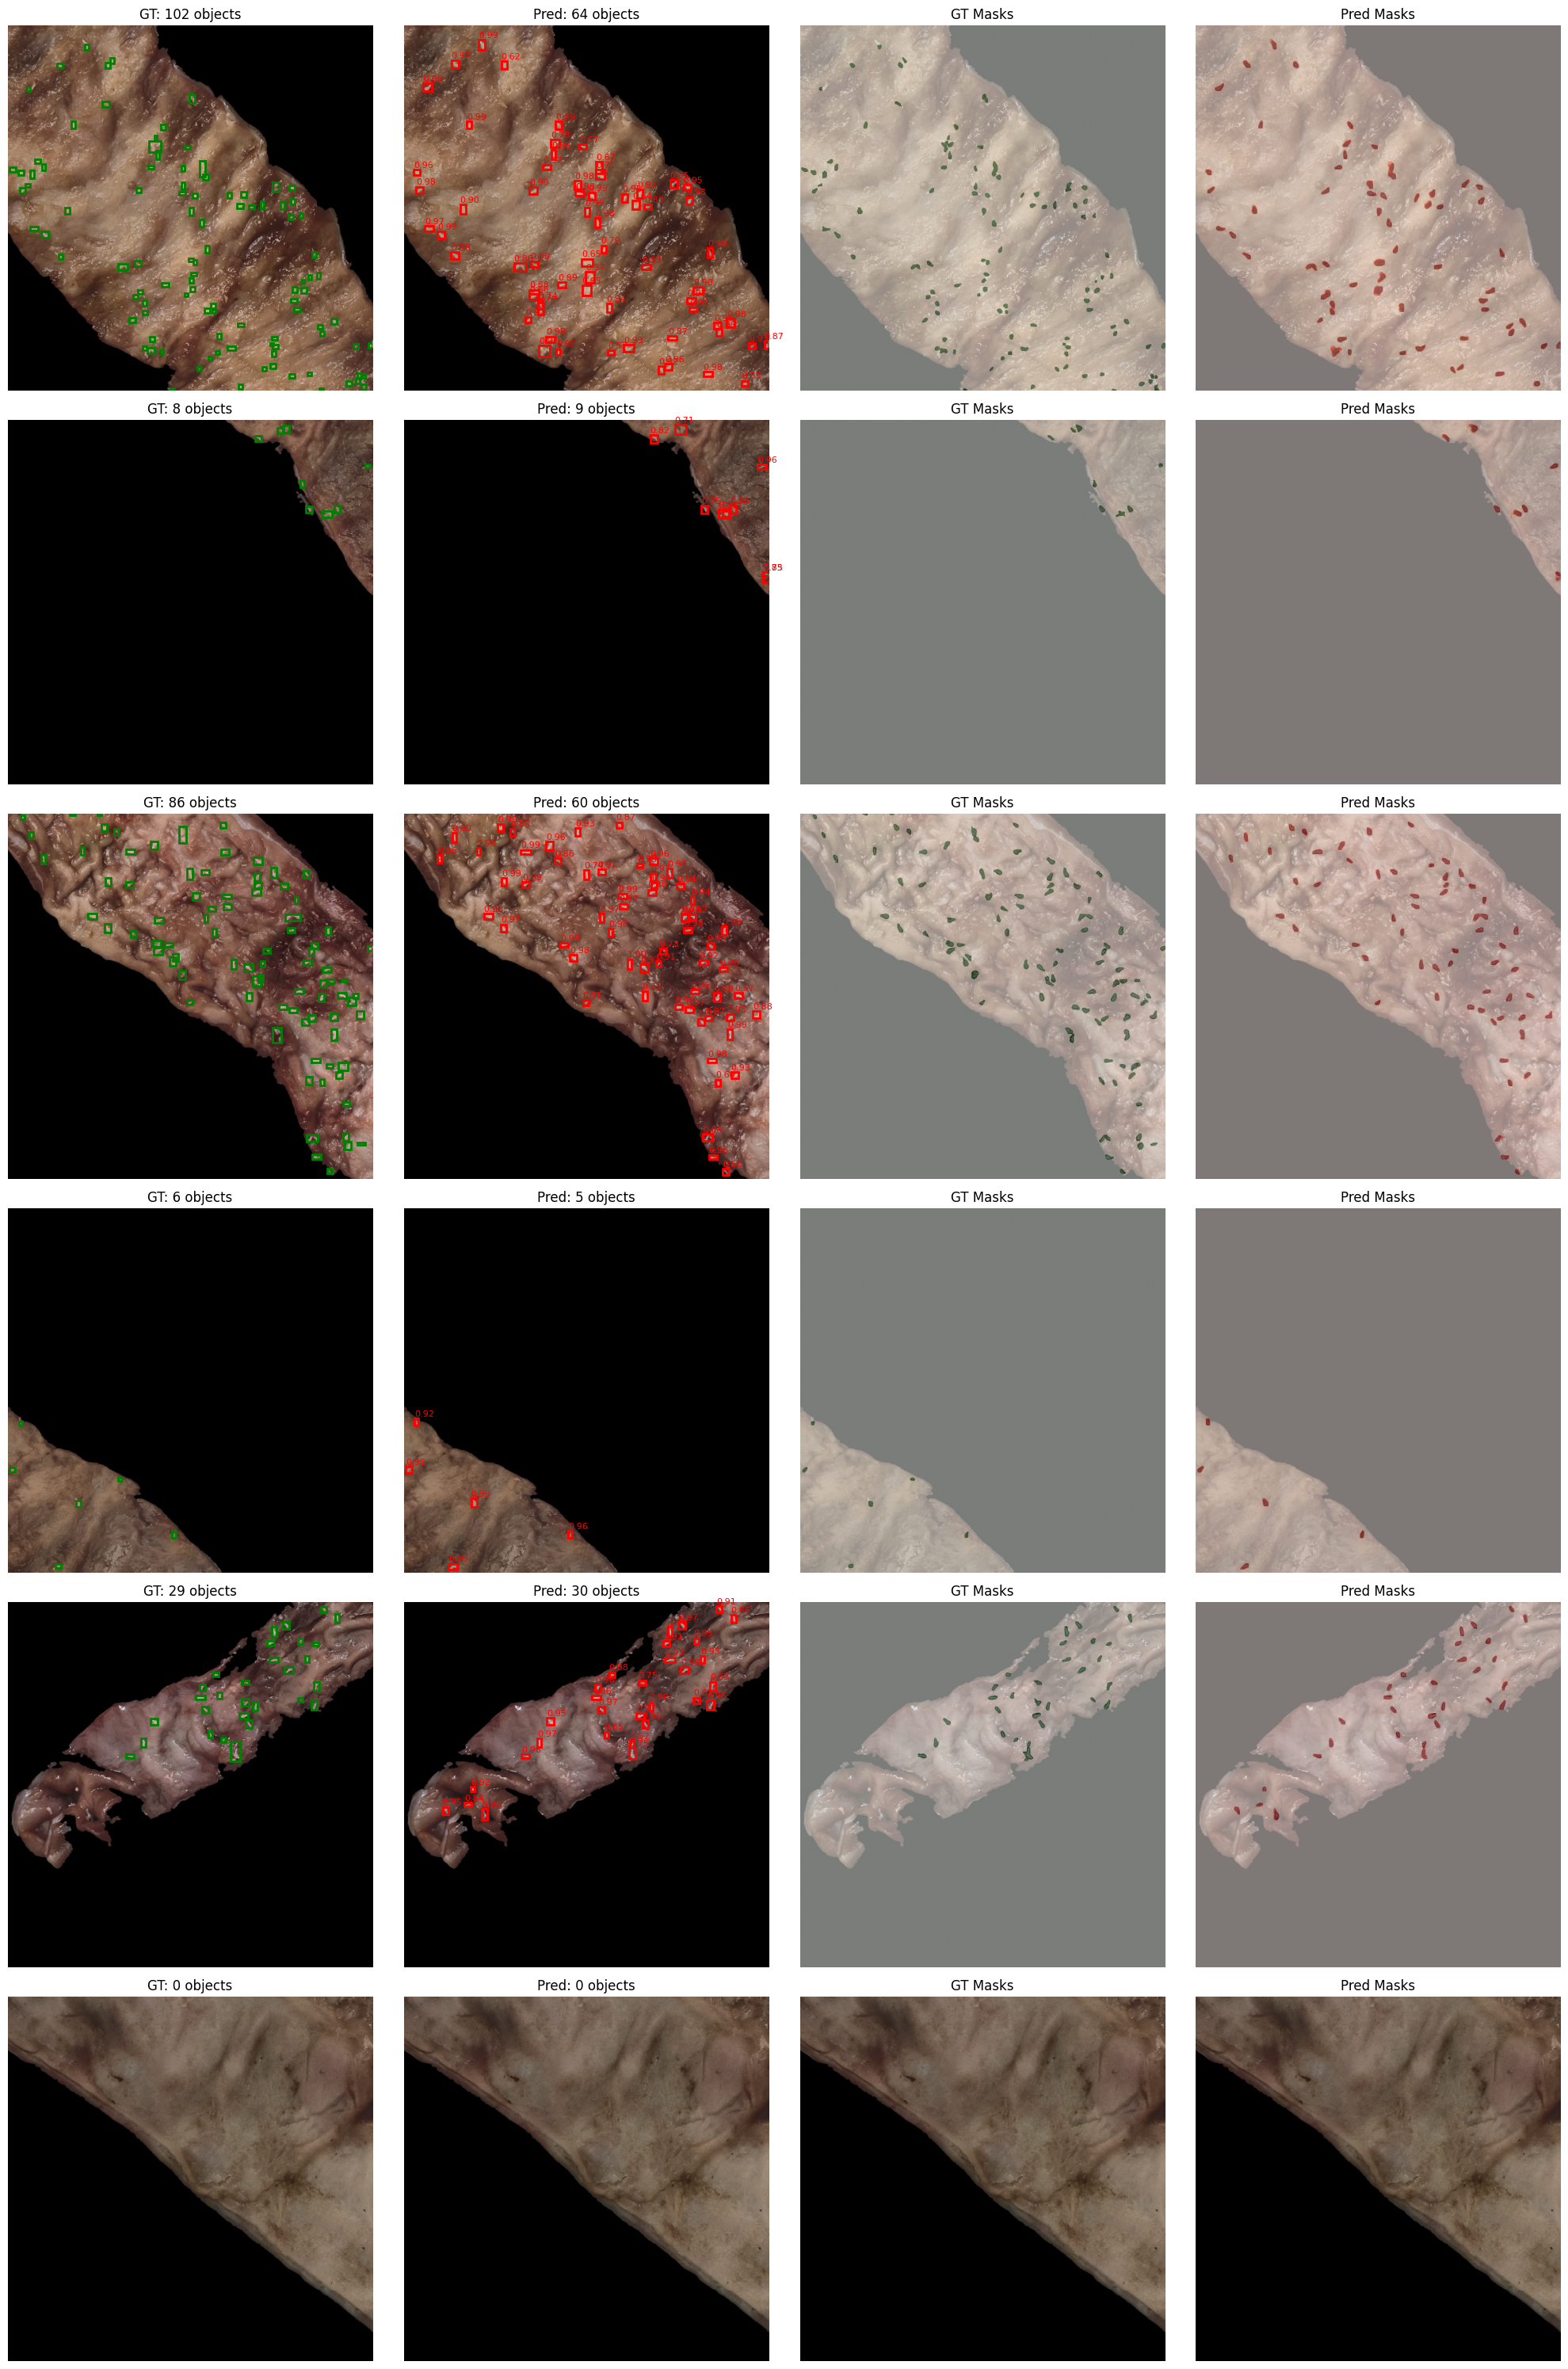

In [ ]:
# Training configuration
config = {
        'exp_name': 'MaskRCNN_v1_corrected',
        'batch_size': 1,
        'num_epochs': 20,
        'learning_rate': 1e-4,
        'optimizer': 'adamw',
        'weight_decay': 1e-4,
        'freeze_backbone': True,
        'freeze_epochs': 5,
        'grad_clip': 1.0,
        'scheduler': 'cosine',
        'early_stop_patience': 15
    }

# Train
history, trainer = train_maskrcnn(
        train_dataset=train_dataset,
        val_dataset=val_dataset,
        config=config,
        checkpoint_dir='checkpoints'
    )

# Evaluate on test set
test_metrics = evaluate_on_test(trainer, test_dataset, score_threshold=0.5)

# Visualize predictions
visualize_predictions(trainer, test_dataset, num_samples=6, score_threshold=0.5)


Train: 28 images
Val:   7 images
Test:  6 images
Loaded 250 samples (augment=True)
Loaded 43 samples (augment=False)
Loaded 42 samples (augment=False)

Dataset sizes:
  Train: 250 tiles
  Val:   43 tiles
  Test:  42 tiles

Sample check:
  Image shape: torch.Size([3, 1024, 1024])
  Num objects: 0
  Boxes shape: torch.Size([0, 4])
  Masks shape: torch.Size([0, 1024, 1024])
Backbone frozen
Model initialized with 19,025,947 trainable parameters

Starting training: MaskRCNN_v1_corrected
Train: 250, Val: 43, Batch: 1, Epochs: 15


Epoch 1/15 [Train]: 100%|██████████| 250/250 [01:01<00:00,  4.04it/s, loss=1.2596]



Epoch 1/15 | LR: 1.00e-04
  Train Loss: 1.1724
  Val Loss: 0.5600 | F1: 0.4184
  Precision: 0.3159 | Recall: 0.6196
  Mask IoU: 0.7807 | Mask Dice: 0.8738
  TP: 259 | FP: 561 | FN: 159
  ★ New best model! (F1: 0.4184)


Epoch 2/15 [Train]: 100%|██████████| 250/250 [01:00<00:00,  4.11it/s, loss=0.8025]



Epoch 2/15 | LR: 9.89e-05
  Train Loss: 0.8678
  Val Loss: 0.5161 | F1: 0.4826
  Precision: 0.3981 | Recall: 0.6124
  Mask IoU: 0.8047 | Mask Dice: 0.8878
  TP: 256 | FP: 387 | FN: 162
  ★ New best model! (F1: 0.4826)


...


Epoch 15/15 | LR: 7.52e-05
  Train Loss: 0.6139
  Val Loss: 0.4632 | F1: 0.4683
  Precision: 0.3422 | Recall: 0.7416
  Mask IoU: 0.7977 | Mask Dice: 0.8840
  TP: 310 | FP: 596 | FN: 108
  No improvement (6/15)

Training complete! Best F1: 0.5230

STANDARD EVALUATION


Testing: 100%|██████████| 42/42 [00:14<00:00,  2.98it/s]



TEST RESULTS
Score threshold: 0.3 | IoU threshold: 0.5
Precision: 0.6510 | Recall: 0.6851
F1 Score:  0.6676
Mask IoU:  0.7680 | Mask Dice: 0.8643
TP: 472 | FP: 253 | FN: 217


Inference: 100%|██████████| 42/42 [00:10<00:00,  3.84it/s]



EVALUATION AT MULTIPLE THRESHOLDS

--- IoU Threshold: 0.25 ---
Score    Prec     Recall   F1       MaskIoU  Dice    
--------------------------------------------------
0.10     0.5395   0.8026   0.6453   0.7154   0.8219  
0.20     0.6468   0.7896   0.7111   0.7172   0.8235  
0.30     0.7116   0.7736   0.7413   0.7191   0.8249  
0.40     0.7562   0.7562   0.7562   0.7206   0.8261  
0.50     0.7903   0.7329   0.7605   0.7244   0.8292  
0.60     0.8161   0.7083   0.7584   0.7280   0.8317  
0.70     0.8421   0.6734   0.7484   0.7309   0.8338  

--- IoU Threshold: 0.5 ---
Score    Prec     Recall   F1       MaskIoU  Dice    
--------------------------------------------------
0.10     0.4868   0.7242   0.5823   0.7620   0.8602  
0.20     0.5838   0.7126   0.6418   0.7625   0.8604  
0.30     0.6409   0.6967   0.6676   0.7641   0.8616  
0.40     0.6749   0.6749   0.6749   0.7656   0.8626  
0.50     0.7089   0.6575   0.6822   0.7664   0.8631  
0.60     0.7324   0.6357   0.6807   0.7693   0.865

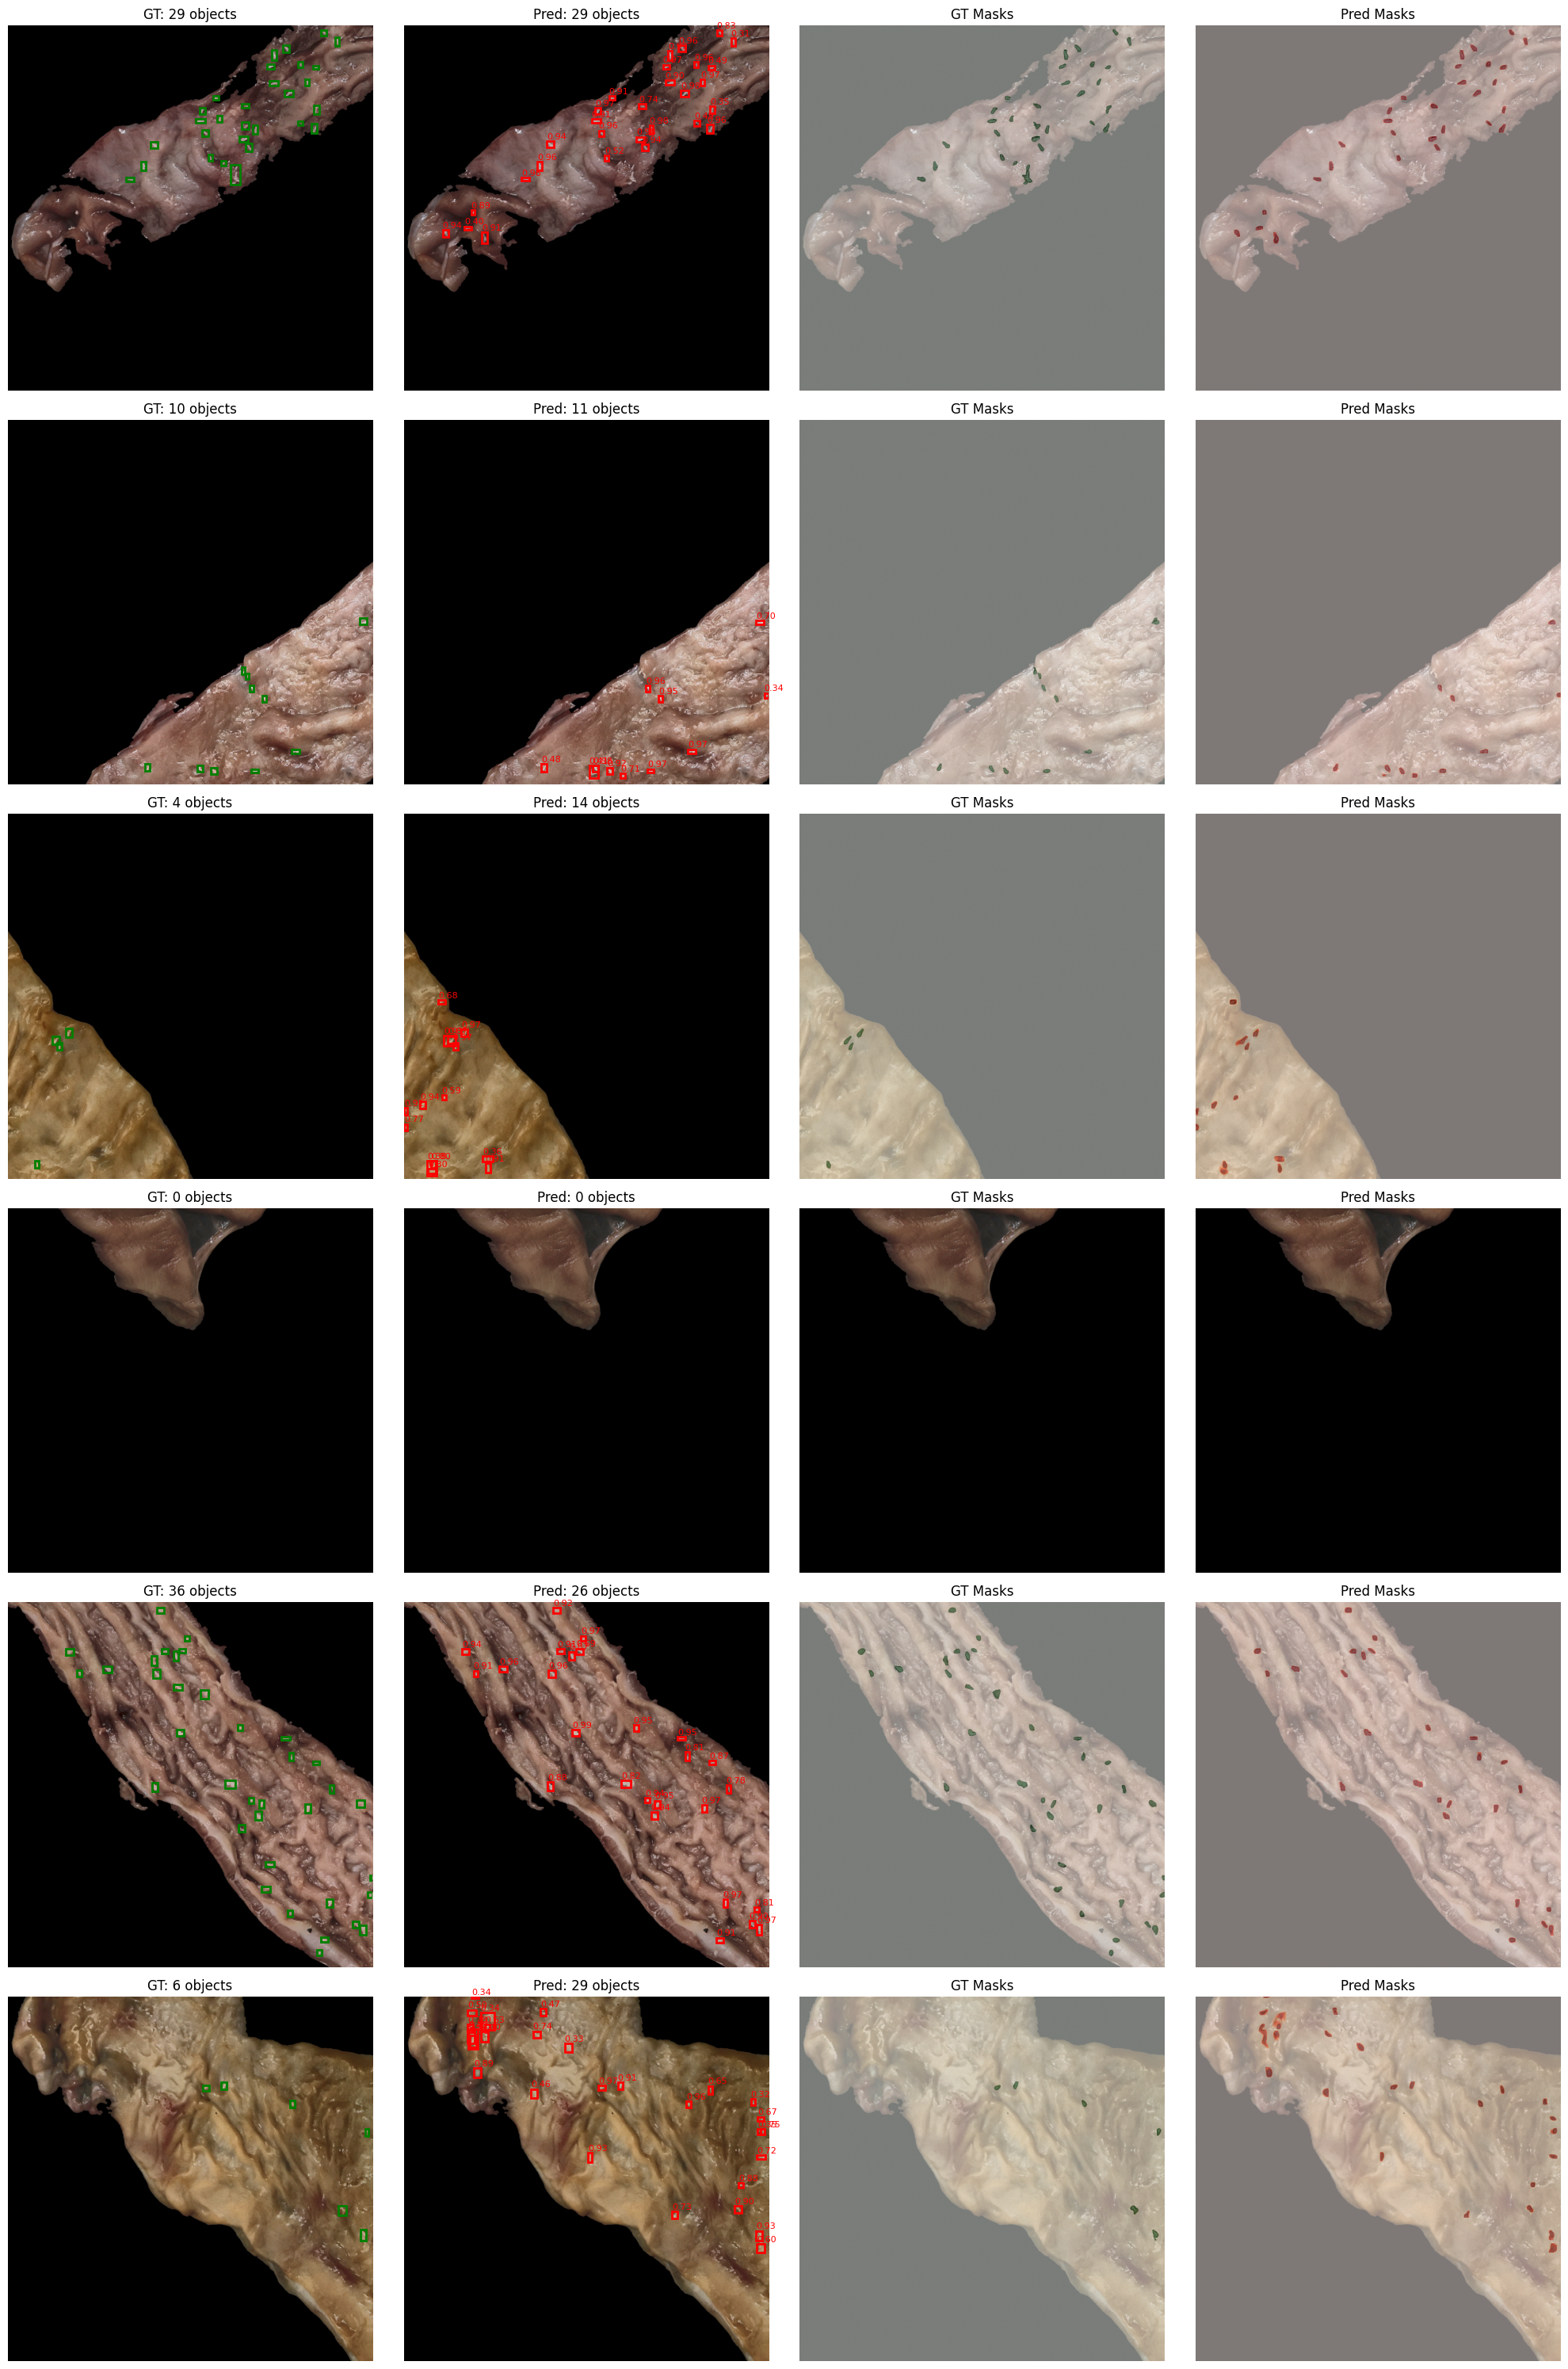

In [ ]:
"""
Mask R-CNN for Parasite Detection in Museum Specimen Images
Corrected version with fixes for:
1. ImageNet normalization for pretrained backbone
2. Proper handling of negative samples during training
3. Confidence-sorted matching in metrics computation
4. Updated Albumentations API (GaussNoise)
5. Single consistent function definitions (no duplicates)

"""

import os
import json
import random
import shutil
from pathlib import Path
from collections import defaultdict

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision.models.detection import maskrcnn_resnet50_fpn_v2
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor

from scipy.ndimage import label as ndimage_label
from skimage.morphology import remove_small_holes, remove_small_objects

import albumentations as A


# =============================================================================
# PREPROCESSING FUNCTIONS
# =============================================================================

def apply_clahe_and_brightness(bgr):
    """Apply CLAHE + brightness boost."""
    img_lab = cv2.cvtColor(bgr, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(img_lab)
    clahe = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8, 8))
    l2 = clahe.apply(l)
    img_lab = cv2.merge((l2, a, b))
    bgr_corr = cv2.cvtColor(img_lab, cv2.COLOR_LAB2BGR)
    hsv = cv2.cvtColor(bgr_corr, cv2.COLOR_BGR2HSV)
    h, s, v = cv2.split(hsv)
    v = cv2.add(v, 15)
    hsv = cv2.merge([h, s, v])
    return cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)


def specimen_mask(bgr, use_hull=False):
    """Generate binary mask for specimen."""
    hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)
    H, S, V = cv2.split(hsv)
    ret, _ = cv2.threshold(V, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    v_thr, s_thr = int(max(ret * 0.7, 25)), 15
    m = ((V >= v_thr) & (S >= s_thr)).astype(np.uint8)
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    m = cv2.morphologyEx(m, cv2.MORPH_OPEN, k)
    m = cv2.morphologyEx(m, cv2.MORPH_CLOSE, k)
    m = remove_small_objects(m.astype(bool), min_size=3000)
    m = remove_small_holes(m, area_threshold=50000).astype(np.uint8)
    n, lab = cv2.connectedComponents(m)
    if n <= 1:
        return np.zeros(m.shape, bool)
    cnts = np.bincount(lab.ravel())[1:]
    keep = 1 + np.argmax(cnts)
    m = (lab == keep).astype(np.uint8)
    if use_hull:
        contours, _ = cv2.findContours(m, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if contours:
            hull = cv2.convexHull(np.vstack(contours))
            m_hull = np.zeros_like(m)
            cv2.drawContours(m_hull, [hull], -1, 1, -1)
            m = m_hull
    return m.astype(bool)


def roi_from_mask(img, mask, pad=10):
    """Extract ROI bounding box."""
    ys, xs = np.where(mask)
    if len(ys) == 0 or len(xs) == 0:
        return None, None, None
    y0, y1 = max(0, ys.min() - pad), min(img.shape[0], ys.max() + pad)
    x0, x1 = max(0, xs.min() - pad), min(img.shape[1], xs.max() + pad)
    return (y0, y1, x0, x1), img[y0:y1, x0:x1], mask[y0:y1, x0:x1]


def get_white_points_from_label(label_img):
    """Extract white pixel coordinates from label image."""
    if len(label_img.shape) == 3:
        gray = cv2.cvtColor(label_img, cv2.COLOR_BGR2GRAY)
    else:
        gray = label_img
    _, thresh = cv2.threshold(gray, 200, 255, cv2.THRESH_BINARY)
    ys, xs = np.where(thresh > 0)
    return [(int(x), int(y)) for x, y in zip(xs, ys)] if len(xs) > 0 else []


def extract_centroids_from_points(points, img_shape):
    """Convert dense point cloud to centroids."""
    if len(points) == 0:
        return []
    binary_mask = np.zeros(img_shape[:2], dtype=np.uint8)
    for x, y in points:
        if 0 <= y < img_shape[0] and 0 <= x < img_shape[1]:
            binary_mask[y, x] = 255
    labeled_mask, num_parasites = ndimage_label(binary_mask)
    centroids = []
    for region_id in range(1, num_parasites + 1):
        ys, xs = np.where(labeled_mask == region_id)
        if len(ys) > 0:
            centroids.append((int(xs.mean()), int(ys.mean())))
    return centroids


# =============================================================================
# INSTANCE MASK CREATION
# =============================================================================

def create_instance_mask_from_centroids(tile_mask, points_local, search_radius=10):
    """
    Convert binary mask to instance mask using centroids.

    Key features:
    1. Tracks which blobs have been assigned to avoid overwriting
    2. Searches nearby pixels if centroid doesn't land on mask
    3. Returns diagnostic info for debugging
    """
    stats = {
        'total_centroids': len(points_local),
        'direct_hits': 0,
        'nearby_hits': 0,
        'missed': 0,
        'duplicate_blob': 0
    }

    if tile_mask is None or len(points_local) == 0:
        return None, stats

    binary_mask = (tile_mask > 0).astype(np.uint8)
    labeled_mask, num_objects = ndimage_label(binary_mask)
    instance_mask = np.zeros_like(labeled_mask, dtype=np.int32)
    used_blobs = set()
    instance_id = 1

    for (x, y) in points_local:
        if not (0 <= y < labeled_mask.shape[0] and 0 <= x < labeled_mask.shape[1]):
            stats['missed'] += 1
            continue

        blob_id = labeled_mask[y, x]

        if blob_id > 0:
            stats['direct_hits'] += 1
        else:
            # Search nearby pixels in expanding squares
            found = False
            for radius in range(1, search_radius + 1):
                for dy in range(-radius, radius + 1):
                    for dx in range(-radius, radius + 1):
                        if abs(dy) != radius and abs(dx) != radius:
                            continue
                        ny, nx = y + dy, x + dx
                        if 0 <= ny < labeled_mask.shape[0] and 0 <= nx < labeled_mask.shape[1]:
                            if labeled_mask[ny, nx] > 0:
                                blob_id = labeled_mask[ny, nx]
                                found = True
                                break
                    if found:
                        break
                if found:
                    stats['nearby_hits'] += 1
                    break
            if not found:
                stats['missed'] += 1
                continue

        if blob_id in used_blobs:
            stats['duplicate_blob'] += 1
            continue

        instance_mask[labeled_mask == blob_id] = instance_id
        used_blobs.add(blob_id)
        instance_id += 1

    return instance_mask, stats


def get_instances_from_mask(instance_mask, min_area=5):
    """Extract individual instance masks and bounding boxes."""
    if instance_mask is None:
        return [], []

    masks, boxes = [], []
    unique_ids = np.unique(instance_mask)
    unique_ids = unique_ids[unique_ids > 0]

    for inst_id in unique_ids:
        mask = (instance_mask == inst_id).astype(np.uint8)
        area = mask.sum()
        if area < min_area:
            continue

        pos = np.where(mask)
        if len(pos[0]) == 0:
            continue

        y_min, y_max = pos[0].min(), pos[0].max()
        x_min, x_max = pos[1].min(), pos[1].max()

        # Ensure non-degenerate boxes
        if x_max <= x_min:
            x_max = x_min + 1
        if y_max <= y_min:
            y_max = y_min + 1

        masks.append(mask)
        boxes.append([x_min, y_min, x_max, y_max])

    return masks, boxes


# =============================================================================
# TILE GENERATION
# =============================================================================

def split_images_fixed_grid(original_img, label_img, mask_img, points, tile_size=1024):
    """Split images into fixed tile_size grid."""
    height, width = original_img.shape[:2]
    tiles = []
    tile_count = 0
    total_stats = {'direct_hits': 0, 'nearby_hits': 0, 'missed': 0, 'duplicate_blob': 0}

    for y in range(0, height, tile_size):
        for x in range(0, width, tile_size):
            x1, y1 = x, y
            x2, y2 = min(x + tile_size, width), min(y + tile_size, height)

            tile_original = original_img[y1:y2, x1:x2]
            tile_label = label_img[y1:y2, x1:x2]
            tile_mask = mask_img[y1:y2, x1:x2] if mask_img is not None else None

            actual_h, actual_w = tile_original.shape[:2]
            if actual_h < tile_size or actual_w < tile_size:
                padded_original = np.zeros((tile_size, tile_size, 3), dtype=np.uint8)
                padded_original[:actual_h, :actual_w] = tile_original

                if len(tile_label.shape) == 3:
                    padded_label = np.zeros((tile_size, tile_size, 3), dtype=np.uint8)
                else:
                    padded_label = np.zeros((tile_size, tile_size), dtype=np.uint8)
                padded_label[:actual_h, :actual_w] = tile_label

                padded_mask = None
                if tile_mask is not None:
                    padded_mask = np.zeros((tile_size, tile_size), dtype=np.uint8)
                    padded_mask[:actual_h, :actual_w] = tile_mask

                tile_original, tile_label, tile_mask = padded_original, padded_label, padded_mask

            # Skip completely empty tiles
            if tile_original.mean() < 5:
                continue

            tile_points = [(px - x1, py - y1) for px, py in points if x1 <= px < x2 and y1 <= py < y2]

            instance_mask = None
            if len(tile_points) > 0 and tile_mask is not None:
                instance_mask, stats = create_instance_mask_from_centroids(tile_mask, tile_points)
                for key in total_stats:
                    total_stats[key] += stats.get(key, 0)

            tiles.append({
                'tile_original': tile_original,
                'tile_label': tile_label,
                'tile_mask': tile_mask,
                'instance_mask': instance_mask,
                'points_local': tile_points,
                'tile_id': f"tile_{tile_count:04d}",
                'global_bbox': (x1, y1, x2, y2),
                'num_parasites': len(tile_points),
                'is_negative': len(tile_points) == 0
            })
            tile_count += 1

    return tiles, total_stats


def process_image_complete(image_path, label_path, mask_path, image_id,
                          tile_size=1024, apply_clahe=True, extract_roi=True):
    """Complete preprocessing pipeline."""
    img = cv2.imread(image_path)
    label = cv2.imread(label_path)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE) if mask_path and os.path.exists(mask_path) else None

    if img is None or label is None:
        print(f"Warning: Could not read {image_id}")
        return [], {}

    original_shape = img.shape
    if apply_clahe:
        img = apply_clahe_and_brightness(img)

    roi_bbox = None
    if extract_roi:
        specimen_m = specimen_mask(img, use_hull=False)
        bbox, img_roi, mask_roi = roi_from_mask(img, specimen_m, pad=10)
        if bbox is None:
            img_roi, label_roi, mask_roi_img = img, label, mask
        else:
            y0, y1, x0, x1 = bbox
            roi_bbox = bbox
            img_roi = img_roi.copy()
            img_roi[~mask_roi] = 0
            label_roi = label[y0:y1, x0:x1]
            mask_roi_img = mask[y0:y1, x0:x1] if mask is not None else None
    else:
        img_roi, label_roi, mask_roi_img = img, label, mask

    points = get_white_points_from_label(label_roi)
    if len(points) == 0:
        print(f"Warning: No points found in {image_id}")
        return [], {}

    centroids = extract_centroids_from_points(points, label_roi.shape)
    print(f"  [{image_id}] {len(points)} pixels -> {len(centroids)} centroids")

    if len(centroids) == 0:
        print(f"Warning: No centroids extracted for {image_id}")
        return [], {}

    tiles, stats = split_images_fixed_grid(
        img_roi, label_roi, mask_roi_img, centroids,
        tile_size=tile_size
    )

    for tile in tiles:
        tile['image_id'] = f"{image_id}_{tile['tile_id']}"
        tile['base_image_id'] = image_id
        tile['original_shape'] = original_shape
        tile['roi_bbox'] = roi_bbox

    return tiles, stats


# =============================================================================
# DATASET CLASS
# =============================================================================

class ParasiteDataset(Dataset):
    """
    Mask R-CNN dataset with proper instance masks and augmentation.

    FIXES:
    - Updated Albumentations API (std_range instead of var_limit)
    - Handles both positive and negative samples correctly
    """

    def __init__(self, image_ids, output_dir, augment=False, min_area=10):
        self.augment = augment
        self.min_area = min_area
        self.samples = []

        if augment:
            self.transform = A.Compose([
                A.HorizontalFlip(p=0.5),
                A.VerticalFlip(p=0.5),
                A.RandomRotate90(p=0.5),
                A.OneOf([
                    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=1.0),
                    A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=20, p=1.0),
                ], p=0.3),
                # FIX: Updated GaussNoise API - use std_range instead of var_limit
                A.GaussNoise(std_range=(0.02, 0.1), p=0.2),
                A.GaussianBlur(blur_limit=(3, 5), p=0.1),
            ])
        else:
            self.transform = None

        for img_id in image_ids:
            tiles_dir = os.path.join(output_dir, img_id, "tiles")
            if not os.path.exists(tiles_dir):
                continue
            for tile_file in os.listdir(tiles_dir):
                if tile_file.endswith('.png'):
                    tile_id = tile_file.replace('.png', '')
                    sample = {
                        'tile_path': os.path.join(tiles_dir, tile_file),
                        'instance_mask_path': os.path.join(output_dir, img_id, "masks", f"{tile_id}_instance.npy"),
                        'anno_path': os.path.join(output_dir, img_id, "annotations", f"{tile_id}.json"),
                        'base_image_id': img_id,
                        'tile_id': tile_id
                    }
                    if os.path.exists(sample['instance_mask_path']) and os.path.exists(sample['anno_path']):
                        self.samples.append(sample)

        print(f"Loaded {len(self.samples)} samples (augment={augment})")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        image = cv2.imread(sample['tile_path'])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        instance_mask = np.load(sample['instance_mask_path'])

        # Extract masks and boxes
        masks, boxes = [], []
        unique_ids = np.unique(instance_mask)
        unique_ids = unique_ids[unique_ids > 0]

        for inst_id in unique_ids:
            mask = (instance_mask == inst_id).astype(np.uint8)
            if mask.sum() < self.min_area:
                continue
            pos = np.where(mask)
            if len(pos[0]) == 0:
                continue
            y_min, y_max = pos[0].min(), pos[0].max()
            x_min, x_max = pos[1].min(), pos[1].max()
            # Ensure non-degenerate boxes
            if x_max <= x_min:
                x_max = x_min + 1
            if y_max <= y_min:
                y_max = y_min + 1
            masks.append(mask)
            boxes.append([x_min, y_min, x_max, y_max])

        # Apply augmentation
        if self.transform and len(masks) > 0:
            transformed = self.transform(image=image, masks=masks)
            image = transformed['image']
            masks, boxes = [], []
            for aug_mask in transformed['masks']:
                aug_mask = (aug_mask > 0.5).astype(np.uint8)
                if aug_mask.sum() < self.min_area:
                    continue
                pos = np.where(aug_mask)
                if len(pos[0]) == 0:
                    continue
                y_min, y_max = pos[0].min(), pos[0].max()
                x_min, x_max = pos[1].min(), pos[1].max()
                if x_max <= x_min:
                    x_max = x_min + 1
                if y_max <= y_min:
                    y_max = y_min + 1
                masks.append(aug_mask)
                boxes.append([x_min, y_min, x_max, y_max])

        # Create target
        if not masks:
            target = {
                'boxes': torch.zeros((0, 4), dtype=torch.float32),
                'labels': torch.zeros(0, dtype=torch.int64),
                'masks': torch.zeros((0, image.shape[0], image.shape[1]), dtype=torch.uint8),
                'image_id': torch.tensor([idx]),
                'area': torch.zeros(0, dtype=torch.float32),
                'iscrowd': torch.zeros(0, dtype=torch.int64)
            }
        else:
            boxes_tensor = torch.as_tensor(boxes, dtype=torch.float32)
            masks_tensor = torch.as_tensor(np.stack(masks), dtype=torch.uint8)
            areas = (boxes_tensor[:, 3] - boxes_tensor[:, 1]) * (boxes_tensor[:, 2] - boxes_tensor[:, 0])
            target = {
                'boxes': boxes_tensor,
                'labels': torch.ones(len(boxes), dtype=torch.int64),
                'masks': masks_tensor,
                'image_id': torch.tensor([idx]),
                'area': areas,
                'iscrowd': torch.zeros(len(boxes), dtype=torch.int64)
            }

        # Simple normalization to [0, 1]
        image = torch.as_tensor(image, dtype=torch.float32).permute(2, 0, 1) / 255.0

        return image, target


def collate_fn(batch):
    """Custom collate function for detection models."""
    return tuple(zip(*batch))


# =============================================================================
# MODEL
# =============================================================================

def get_maskrcnn_model(num_classes=2, pretrained=True):
    """Initialize Mask R-CNN with custom head."""
    model = maskrcnn_resnet50_fpn_v2(weights="DEFAULT" if pretrained else None)
    in_features_box = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features_box, num_classes)
    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    model.roi_heads.mask_predictor = MaskRCNNPredictor(in_features_mask, 256, num_classes)
    return model


# =============================================================================
# TRAINER CLASS
# =============================================================================

class MaskRCNNTrainer:
    """
    Mask R-CNN Trainer with proper metrics computation.

    FIXES:
    - Proper handling of negative samples (empty targets)
    - Confidence-sorted matching in metrics computation
    """

    def __init__(self, num_classes=2, device='cuda', learning_rate=1e-4,
                 optimizer_type='adamw', weight_decay=1e-4,
                 freeze_backbone=False, freeze_epochs=0, grad_clip=1.0):
        self.device = device
        self.grad_clip = grad_clip
        self.freeze_epochs = freeze_epochs
        self.current_epoch = 0

        self.model = get_maskrcnn_model(num_classes)
        self.backbone_frozen = freeze_backbone
        if freeze_backbone:
            self._freeze_backbone()
        self.model.to(device)

        params = [p for p in self.model.parameters() if p.requires_grad]
        if optimizer_type.lower() == 'adam':
            self.optimizer = torch.optim.Adam(params, lr=learning_rate)
        elif optimizer_type.lower() == 'adamw':
            self.optimizer = torch.optim.AdamW(params, lr=learning_rate, weight_decay=weight_decay)
        elif optimizer_type.lower() == 'sgd':
            self.optimizer = torch.optim.SGD(params, lr=learning_rate, momentum=0.9, weight_decay=weight_decay)

        print(f"Model initialized with {sum(p.numel() for p in params):,} trainable parameters")

    def _freeze_backbone(self):
        for param in self.model.backbone.parameters():
            param.requires_grad = False
        self.backbone_frozen = True
        print("Backbone frozen")

    def _unfreeze_backbone(self):
        for param in self.model.backbone.parameters():
            param.requires_grad = True
        self.backbone_frozen = False
        params = [p for p in self.model.parameters() if p.requires_grad]
        lr = self.optimizer.param_groups[0]['lr']
        self.optimizer = torch.optim.AdamW(params, lr=lr)
        print("Backbone unfrozen")

    def train_step(self, images, targets):
        """
        Training step - FIX: Include negative samples in training.

        Mask R-CNN internally handles empty targets and learns to produce
        no detections for background regions.
        """
        self.model.train()
        self.optimizer.zero_grad()

        images = [img.to(self.device) for img in images]
        targets = [{k: v.to(self.device) for k, v in t.items()} for t in targets]

        # FIX: Pass ALL samples to model, including empty ones
        # Mask R-CNN handles empty targets internally via RPN
        # This teaches the model that some images have no objects

        # Check if ALL targets are empty
        has_any_objects = any(len(t['boxes']) > 0 for t in targets)

        if not has_any_objects:
            # If batch has NO objects at all, we still forward for RPN loss
            # but we need at least some signal. Return small loss.
            try:
                loss_dict = self.model(images, targets)
                losses = sum(loss for loss in loss_dict.values())
            except:
                # Some versions of torchvision don't handle all-empty batches
                return {'loss': 0.0, 'loss_classifier': 0.0, 'loss_box_reg': 0.0,
                        'loss_mask': 0.0, 'loss_objectness': 0.0, 'loss_rpn_box_reg': 0.0}
        else:
            loss_dict = self.model(images, targets)
            losses = sum(loss for loss in loss_dict.values())

        if torch.isnan(losses):
            print("Warning: NaN loss detected")
            return {'loss': 0.0, 'loss_classifier': 0.0, 'loss_box_reg': 0.0,
                    'loss_mask': 0.0, 'loss_objectness': 0.0, 'loss_rpn_box_reg': 0.0}

        losses.backward()
        if self.grad_clip:
            torch.nn.utils.clip_grad_norm_(
                [p for p in self.model.parameters() if p.requires_grad],
                max_norm=self.grad_clip
            )
        self.optimizer.step()

        return {
            'loss': losses.item(),
            'loss_classifier': loss_dict.get('loss_classifier', torch.tensor(0.0)).item(),
            'loss_box_reg': loss_dict.get('loss_box_reg', torch.tensor(0.0)).item(),
            'loss_mask': loss_dict.get('loss_mask', torch.tensor(0.0)).item(),
            'loss_objectness': loss_dict.get('loss_objectness', torch.tensor(0.0)).item(),
            'loss_rpn_box_reg': loss_dict.get('loss_rpn_box_reg', torch.tensor(0.0)).item()
        }

    def val_step(self, images, targets):
        """Validation step with loss computation and metrics."""
        images_gpu = [img.to(self.device) for img in images]
        targets_gpu = [{k: v.to(self.device) for k, v in t.items()} for t in targets]

        with torch.no_grad():
            self.model.train()
            valid_indices = [i for i, t in enumerate(targets_gpu) if len(t['boxes']) > 0]
            if len(valid_indices) > 0:
                loss_dict = self.model(
                    [images_gpu[i] for i in valid_indices],
                    [targets_gpu[i] for i in valid_indices]
                )
                losses = sum(loss for loss in loss_dict.values())
            else:
                losses, loss_dict = torch.tensor(0.0), {}

        with torch.no_grad():
            self.model.eval()
            predictions = self.model(images_gpu)

        metrics = self.compute_metrics(predictions, targets_gpu)

        return {
            'loss': losses.item() if torch.is_tensor(losses) else losses,
            'loss_classifier': loss_dict.get('loss_classifier', torch.tensor(0.0)).item(),
            'loss_box_reg': loss_dict.get('loss_box_reg', torch.tensor(0.0)).item(),
            'loss_mask': loss_dict.get('loss_mask', torch.tensor(0.0)).item(),
            'loss_objectness': loss_dict.get('loss_objectness', torch.tensor(0.0)).item(),
            'loss_rpn_box_reg': loss_dict.get('loss_rpn_box_reg', torch.tensor(0.0)).item(),
            **metrics
        }

    def compute_metrics(self, predictions, targets, iou_threshold=0.5, score_threshold=0.3,
                        use_mask_iou_for_matching=True):
        """
        Compute detection metrics.

        Args:
            predictions: Model predictions
            targets: Ground truth targets
            iou_threshold: IoU threshold for matching (default 0.5)
            score_threshold: Confidence threshold for predictions (default 0.3 - lowered!)
            use_mask_iou_for_matching: If True, match by mask IoU instead of box IoU.
                                       Better for small objects like parasites.

        Returns:
            Dictionary with TP, FP, FN, mask IoU, mask Dice
        """
        total_tp, total_fp, total_fn = 0, 0, 0
        total_mask_iou, total_mask_dice, num_matched = 0.0, 0.0, 0

        for pred, target in zip(predictions, targets):
            pred_boxes = pred['boxes']
            pred_scores = pred['scores']
            pred_masks = pred['masks']
            target_boxes = target['boxes']
            target_masks = target['masks']

            # Filter by score threshold
            keep = pred_scores > score_threshold
            pred_boxes = pred_boxes[keep]
            pred_scores = pred_scores[keep]
            pred_masks = pred_masks[keep]

            num_preds, num_gts = len(pred_boxes), len(target_boxes)

            # Handle edge cases
            if num_preds == 0 and num_gts == 0:
                continue
            elif num_preds == 0:
                total_fn += num_gts
                continue
            elif num_gts == 0:
                total_fp += num_preds
                continue

            # Sort predictions by confidence (descending)
            sorted_indices = torch.argsort(pred_scores, descending=True)
            pred_boxes = pred_boxes[sorted_indices]
            pred_scores = pred_scores[sorted_indices]
            pred_masks = pred_masks[sorted_indices]

            # Compute IoU matrix for matching
            if use_mask_iou_for_matching:
                # Use MASK IoU for matching - better for small objects
                iou_matrix = self._compute_mask_iou_matrix(pred_masks, target_masks)
            else:
                # Use box IoU for matching
                iou_matrix = self.box_iou(pred_boxes, target_boxes)

            matched_gt = set()

            for i in range(num_preds):
                if len(matched_gt) == num_gts:
                    total_fp += (num_preds - i)
                    break

                # Find best matching GT for this prediction
                ious = iou_matrix[i].clone()

                # Mask out already matched GTs
                for matched_idx in matched_gt:
                    ious[matched_idx] = 0

                max_iou = ious.max()
                max_idx = ious.argmax().item()

                if max_iou > iou_threshold:
                    total_tp += 1
                    matched_gt.add(max_idx)

                    # Compute mask metrics for matched pair
                    pred_mask_binary = pred_masks[i, 0] > 0.5
                    gt_mask_binary = target_masks[max_idx] > 0.5

                    mask_iou = self.mask_iou(pred_mask_binary, gt_mask_binary)
                    mask_dice = self.mask_dice(pred_mask_binary, gt_mask_binary)

                    total_mask_iou += mask_iou
                    total_mask_dice += mask_dice
                    num_matched += 1
                else:
                    total_fp += 1

            total_fn += (num_gts - len(matched_gt))

        return {
            'tp': total_tp,
            'fp': total_fp,
            'fn': total_fn,
            'total_mask_iou': total_mask_iou,
            'total_mask_dice': total_mask_dice,
            'num_matched': num_matched
        }

    def _compute_mask_iou_matrix(self, pred_masks, target_masks):
        """Compute pairwise mask IoU matrix [num_preds, num_gts]."""
        num_preds = len(pred_masks)
        num_gts = len(target_masks)

        iou_matrix = torch.zeros((num_preds, num_gts), device=pred_masks.device)

        for i in range(num_preds):
            pred_binary = pred_masks[i, 0] > 0.5
            for j in range(num_gts):
                gt_binary = target_masks[j] > 0.5
                intersection = (pred_binary & gt_binary).sum().float()
                union = (pred_binary | gt_binary).sum().float()
                iou_matrix[i, j] = intersection / (union + 1e-7)

        return iou_matrix

    @staticmethod
    def compute_final_metrics(total_tp, total_fp, total_fn, total_mask_iou, num_matched, total_mask_dice=0.0):
        """Compute final precision, recall, F1, IoU, and Dice."""
        precision = total_tp / (total_tp + total_fp + 1e-7)
        recall = total_tp / (total_tp + total_fn + 1e-7)
        f1 = 2 * precision * recall / (precision + recall + 1e-7)
        avg_mask_iou = total_mask_iou / (num_matched + 1e-7)
        avg_mask_dice = total_mask_dice / (num_matched + 1e-7)
        return {
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'iou': avg_mask_iou,
            'dice': avg_mask_dice
        }

    @staticmethod
    def box_iou(boxes1, boxes2):
        """Compute IoU between two sets of boxes."""
        area1 = (boxes1[:, 2] - boxes1[:, 0]) * (boxes1[:, 3] - boxes1[:, 1])
        area2 = (boxes2[:, 2] - boxes2[:, 0]) * (boxes2[:, 3] - boxes2[:, 1])
        lt = torch.max(boxes1[:, None, :2], boxes2[:, :2])
        rb = torch.min(boxes1[:, None, 2:], boxes2[:, 2:])
        wh = (rb - lt).clamp(min=0)
        inter = wh[:, :, 0] * wh[:, :, 1]
        union = area1[:, None] + area2 - inter
        return inter / (union + 1e-7)

    @staticmethod
    def mask_iou(mask1, mask2):
        """Compute IoU between two binary masks."""
        intersection = (mask1 & mask2).sum().float()
        union = (mask1 | mask2).sum().float()
        return (intersection / (union + 1e-7)).item()

    @staticmethod
    def mask_dice(mask1, mask2):
        """Compute Dice coefficient between two binary masks."""
        intersection = (mask1 & mask2).sum().float()
        total = mask1.sum().float() + mask2.sum().float()
        return (2 * intersection / (total + 1e-7)).item()

    def save_checkpoint(self, path):
        """Save model checkpoint."""
        torch.save({
            'model_state_dict': self.model.state_dict(),
            'optimizer_state_dict': self.optimizer.state_dict(),
            'epoch': self.current_epoch
        }, path)

    def load_checkpoint(self, path):
        """Load model checkpoint."""
        checkpoint = torch.load(path, map_location=self.device)
        self.model.load_state_dict(checkpoint['model_state_dict'])
        if 'optimizer_state_dict' in checkpoint:
            self.optimizer.load_state_dict(checkpoint['optimizer_state_dict'])


# =============================================================================
# TRAINING FUNCTION
# =============================================================================

def train_maskrcnn(train_dataset, val_dataset, config, checkpoint_dir='checkpoints'):
    """Main training function."""
    exp_name = config.get('exp_name', 'maskrcnn')
    batch_size = config.get('batch_size', 2)
    num_epochs = config.get('num_epochs', 30)
    learning_rate = config.get('learning_rate', 1e-4)
    optimizer_type = config.get('optimizer', 'adamw')
    weight_decay = config.get('weight_decay', 1e-4)
    freeze_backbone = config.get('freeze_backbone', False)
    freeze_epochs = config.get('freeze_epochs', 0)
    grad_clip = config.get('grad_clip', 1.0)
    scheduler_type = config.get('scheduler', 'cosine')
    early_stop_patience = config.get('early_stop_patience', 10)

    save_dir = os.path.join(checkpoint_dir, exp_name)
    os.makedirs(save_dir, exist_ok=True)

    train_loader = DataLoader(
        train_dataset, batch_size=batch_size, shuffle=True,
        collate_fn=collate_fn, num_workers=2, pin_memory=True
    )
    val_loader = DataLoader(
        val_dataset, batch_size=batch_size, shuffle=False,
        collate_fn=collate_fn, num_workers=2, pin_memory=True
    )

    device = "cuda" if torch.cuda.is_available() else "cpu"
    trainer = MaskRCNNTrainer(
        num_classes=2, device=device, learning_rate=learning_rate,
        optimizer_type=optimizer_type, weight_decay=weight_decay,
        freeze_backbone=freeze_backbone, freeze_epochs=freeze_epochs,
        grad_clip=grad_clip
    )

    scheduler = None
    if scheduler_type == 'cosine':
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            trainer.optimizer, T_max=num_epochs, eta_min=1e-6
        )
    elif scheduler_type == 'plateau':
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            trainer.optimizer, mode='max', factor=0.5, patience=5
        )

    history = {
        'train_loss': [], 'val_loss': [],
        'val_precision': [], 'val_recall': [], 'val_f1': [], 'val_iou': [], 'val_dice': [],
        'learning_rates': []
    }
    best_val_f1, patience_counter = 0.0, 0

    print(f"\nStarting training: {exp_name}")
    print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Batch: {batch_size}, Epochs: {num_epochs}")
    print("=" * 60)

    for epoch in range(num_epochs):
        trainer.current_epoch = epoch
        if trainer.backbone_frozen and epoch >= freeze_epochs:
            trainer._unfreeze_backbone()

        # Training
        train_losses = []
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]")
        for images, targets in pbar:
            metrics = trainer.train_step(images, targets)
            train_losses.append(metrics['loss'])
            pbar.set_postfix({'loss': f"{metrics['loss']:.4f}"})

        # Validation
        val_losses = []
        val_tp, val_fp, val_fn, val_mask_iou, val_mask_dice, val_matched = 0, 0, 0, 0.0, 0.0, 0
        for images, targets in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]", leave=False):
            step_results = trainer.val_step(images, targets)
            val_losses.append(step_results['loss'])
            val_tp += step_results['tp']
            val_fp += step_results['fp']
            val_fn += step_results['fn']
            val_mask_iou += step_results['total_mask_iou']
            val_mask_dice += step_results['total_mask_dice']
            val_matched += step_results['num_matched']

        val_metrics = trainer.compute_final_metrics(val_tp, val_fp, val_fn, val_mask_iou, val_matched, val_mask_dice)

        avg_train_loss, avg_val_loss = np.mean(train_losses), np.mean(val_losses)
        current_lr = trainer.optimizer.param_groups[0]['lr']

        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['val_precision'].append(val_metrics['precision'])
        history['val_recall'].append(val_metrics['recall'])
        history['val_f1'].append(val_metrics['f1'])
        history['val_iou'].append(val_metrics['iou'])
        history['val_dice'].append(val_metrics['dice'])
        history['learning_rates'].append(current_lr)

        print(f"\nEpoch {epoch+1}/{num_epochs} | LR: {current_lr:.2e}")
        print(f"  Train Loss: {avg_train_loss:.4f}")
        print(f"  Val Loss: {avg_val_loss:.4f} | F1: {val_metrics['f1']:.4f}")
        print(f"  Precision: {val_metrics['precision']:.4f} | Recall: {val_metrics['recall']:.4f}")
        print(f"  Mask IoU: {val_metrics['iou']:.4f} | Mask Dice: {val_metrics['dice']:.4f}")
        print(f"  TP: {val_tp} | FP: {val_fp} | FN: {val_fn}")

        if scheduler:
            if scheduler_type == 'plateau':
                scheduler.step(val_metrics['f1'])
            else:
                scheduler.step()

        if val_metrics['f1'] > best_val_f1:
            best_val_f1 = val_metrics['f1']
            patience_counter = 0
            trainer.save_checkpoint(os.path.join(save_dir, 'best_model.pth'))
            print(f"  ★ New best model! (F1: {best_val_f1:.4f})")
        else:
            patience_counter += 1
            print(f"  No improvement ({patience_counter}/{early_stop_patience})")

        if (epoch + 1) % 5 == 0:
            trainer.save_checkpoint(os.path.join(save_dir, f'epoch_{epoch+1}.pth'))

        if early_stop_patience and patience_counter >= early_stop_patience:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break

        torch.cuda.empty_cache()

    print(f"\n{'='*60}\nTraining complete! Best F1: {best_val_f1:.4f}")
    trainer.load_checkpoint(os.path.join(save_dir, 'best_model.pth'))
    return history, trainer


# =============================================================================
# EVALUATION FUNCTIONS
# =============================================================================

def evaluate_on_test(trainer, test_dataset, score_threshold=0.3, iou_threshold=0.5):
    """Evaluate model on test set with detailed metrics."""
    trainer.model.eval()
    test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, collate_fn=collate_fn)

    total_tp, total_fp, total_fn, total_mask_iou, total_mask_dice, num_matched = 0, 0, 0, 0.0, 0.0, 0

    with torch.no_grad():
        for images, targets in tqdm(test_loader, desc="Testing"):
            step_results = trainer.val_step(images, targets)
            total_tp += step_results['tp']
            total_fp += step_results['fp']
            total_fn += step_results['fn']
            total_mask_iou += step_results['total_mask_iou']
            total_mask_dice += step_results['total_mask_dice']
            num_matched += step_results['num_matched']

    metrics = trainer.compute_final_metrics(total_tp, total_fp, total_fn, total_mask_iou, num_matched, total_mask_dice)

    print("\n" + "="*50 + "\nTEST RESULTS\n" + "="*50)
    print(f"Score threshold: {score_threshold} | IoU threshold: {iou_threshold}")
    print(f"Precision: {metrics['precision']:.4f} | Recall: {metrics['recall']:.4f}")
    print(f"F1 Score:  {metrics['f1']:.4f}")
    print(f"Mask IoU:  {metrics['iou']:.4f} | Mask Dice: {metrics['dice']:.4f}")
    print(f"TP: {total_tp} | FP: {total_fp} | FN: {total_fn}")
    return metrics


def evaluate_at_multiple_thresholds(trainer, test_dataset):
    """
    Evaluate model at multiple score and IoU thresholds.
    This helps understand if the model performs better than single-threshold metrics show.
    """
    trainer.model.eval()
    test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, collate_fn=collate_fn)

    # Collect all predictions first
    all_predictions = []
    all_targets = []

    print("Collecting predictions...")
    with torch.no_grad():
        for images, targets in tqdm(test_loader, desc="Inference"):
            images_gpu = [img.to(trainer.device) for img in images]
            predictions = trainer.model(images_gpu)

            for pred, target in zip(predictions, targets):
                all_predictions.append({
                    'boxes': pred['boxes'].cpu(),
                    'scores': pred['scores'].cpu(),
                    'masks': pred['masks'].cpu()
                })
                all_targets.append({
                    'boxes': target['boxes'],
                    'masks': target['masks']
                })

    # Test different thresholds
    score_thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
    iou_thresholds = [0.25, 0.5, 0.75]

    print("\n" + "="*70)
    print("EVALUATION AT MULTIPLE THRESHOLDS")
    print("="*70)

    results = {}

    for iou_thresh in iou_thresholds:
        print(f"\n--- IoU Threshold: {iou_thresh} ---")
        print(f"{'Score':<8} {'Prec':<8} {'Recall':<8} {'F1':<8} {'MaskIoU':<8} {'Dice':<8}")
        print("-" * 50)

        for score_thresh in score_thresholds:
            # Compute metrics at this threshold combination
            total_tp, total_fp, total_fn = 0, 0, 0
            total_mask_iou, total_mask_dice, num_matched = 0.0, 0.0, 0

            for pred, target in zip(all_predictions, all_targets):
                metrics = _compute_single_image_metrics(
                    pred, target,
                    score_threshold=score_thresh,
                    iou_threshold=iou_thresh,
                    use_mask_iou=True
                )
                total_tp += metrics['tp']
                total_fp += metrics['fp']
                total_fn += metrics['fn']
                total_mask_iou += metrics['mask_iou']
                total_mask_dice += metrics['mask_dice']
                num_matched += metrics['matched']

            precision = total_tp / (total_tp + total_fp + 1e-7)
            recall = total_tp / (total_tp + total_fn + 1e-7)
            f1 = 2 * precision * recall / (precision + recall + 1e-7)
            avg_iou = total_mask_iou / (num_matched + 1e-7)
            avg_dice = total_mask_dice / (num_matched + 1e-7)

            print(f"{score_thresh:<8.2f} {precision:<8.4f} {recall:<8.4f} {f1:<8.4f} {avg_iou:<8.4f} {avg_dice:<8.4f}")

            results[(iou_thresh, score_thresh)] = {
                'precision': precision, 'recall': recall, 'f1': f1,
                'iou': avg_iou, 'dice': avg_dice,
                'tp': total_tp, 'fp': total_fp, 'fn': total_fn
            }

    # Find best F1
    best_key = max(results.keys(), key=lambda k: results[k]['f1'])
    best = results[best_key]
    print(f"\n{'='*70}")
    print(f"BEST F1: {best['f1']:.4f} at IoU={best_key[0]}, Score={best_key[1]}")
    print(f"  Precision: {best['precision']:.4f} | Recall: {best['recall']:.4f}")
    print(f"  Mask IoU: {best['iou']:.4f} | Dice: {best['dice']:.4f}")
    print(f"{'='*70}")

    return results


def _compute_single_image_metrics(pred, target, score_threshold, iou_threshold, use_mask_iou=True):
    """Compute metrics for a single image."""
    pred_boxes = pred['boxes']
    pred_scores = pred['scores']
    pred_masks = pred['masks']
    target_boxes = target['boxes']
    target_masks = target['masks']

    # Filter by score
    keep = pred_scores > score_threshold
    pred_boxes = pred_boxes[keep]
    pred_scores = pred_scores[keep]
    pred_masks = pred_masks[keep]

    num_preds, num_gts = len(pred_boxes), len(target_boxes)

    if num_preds == 0 and num_gts == 0:
        return {'tp': 0, 'fp': 0, 'fn': 0, 'mask_iou': 0, 'mask_dice': 0, 'matched': 0}
    elif num_preds == 0:
        return {'tp': 0, 'fp': 0, 'fn': num_gts, 'mask_iou': 0, 'mask_dice': 0, 'matched': 0}
    elif num_gts == 0:
        return {'tp': 0, 'fp': num_preds, 'fn': 0, 'mask_iou': 0, 'mask_dice': 0, 'matched': 0}

    # Sort by confidence
    sorted_indices = torch.argsort(pred_scores, descending=True)
    pred_boxes = pred_boxes[sorted_indices]
    pred_masks = pred_masks[sorted_indices]

    # Compute IoU matrix
    if use_mask_iou:
        iou_matrix = torch.zeros((num_preds, num_gts))
        for i in range(num_preds):
            pred_binary = pred_masks[i, 0] > 0.5
            for j in range(num_gts):
                gt_binary = target_masks[j] > 0.5
                intersection = (pred_binary & gt_binary).sum().float()
                union = (pred_binary | gt_binary).sum().float()
                iou_matrix[i, j] = intersection / (union + 1e-7)
    else:
        # Box IoU
        area1 = (pred_boxes[:, 2] - pred_boxes[:, 0]) * (pred_boxes[:, 3] - pred_boxes[:, 1])
        area2 = (target_boxes[:, 2] - target_boxes[:, 0]) * (target_boxes[:, 3] - target_boxes[:, 1])
        lt = torch.max(pred_boxes[:, None, :2], target_boxes[:, :2])
        rb = torch.min(pred_boxes[:, None, 2:], target_boxes[:, 2:])
        wh = (rb - lt).clamp(min=0)
        inter = wh[:, :, 0] * wh[:, :, 1]
        union = area1[:, None] + area2 - inter
        iou_matrix = inter / (union + 1e-7)

    # Match predictions to GT
    tp, fp = 0, 0
    total_mask_iou, total_mask_dice, num_matched = 0.0, 0.0, 0
    matched_gt = set()

    for i in range(num_preds):
        if len(matched_gt) == num_gts:
            fp += (num_preds - i)
            break

        ious = iou_matrix[i].clone()
        for idx in matched_gt:
            ious[idx] = 0

        max_iou = ious.max()
        max_idx = ious.argmax().item()

        if max_iou > iou_threshold:
            tp += 1
            matched_gt.add(max_idx)

            # Mask metrics
            pred_binary = pred_masks[i, 0] > 0.5
            gt_binary = target_masks[max_idx] > 0.5
            intersection = (pred_binary & gt_binary).sum().float()
            union = (pred_binary | gt_binary).sum().float()
            total_area = pred_binary.sum().float() + gt_binary.sum().float()

            total_mask_iou += (intersection / (union + 1e-7)).item()
            total_mask_dice += (2 * intersection / (total_area + 1e-7)).item()
            num_matched += 1
        else:
            fp += 1

    fn = num_gts - len(matched_gt)

    return {
        'tp': tp, 'fp': fp, 'fn': fn,
        'mask_iou': total_mask_iou, 'mask_dice': total_mask_dice, 'matched': num_matched
    }


def visualize_predictions(trainer, dataset, num_samples=4, score_threshold=0.5):
    """Visualize model predictions."""
    trainer.model.eval()
    indices = np.random.choice(len(dataset), min(num_samples, len(dataset)), replace=False)

    fig, axes = plt.subplots(num_samples, 4, figsize=(20, 5*num_samples))
    if num_samples == 1:
        axes = axes.reshape(1, -1)

    with torch.no_grad():
        for idx, sample_idx in enumerate(indices):
            image, target = dataset[sample_idx]
            prediction = trainer.model([image.to(trainer.device)])[0]

            keep = prediction['scores'] > score_threshold
            pred_masks = prediction['masks'][keep].cpu().numpy()
            pred_boxes = prediction['boxes'][keep].cpu().numpy()
            pred_scores = prediction['scores'][keep].cpu().numpy()
            gt_masks = target['masks'].cpu().numpy()
            gt_boxes = target['boxes'].cpu().numpy()

            # Image is already in [0, 1] range
            image_np = image.permute(1, 2, 0).cpu().numpy()

            # Image with GT boxes
            axes[idx, 0].imshow(image_np)
            for box in gt_boxes:
                rect = patches.Rectangle(
                    (box[0], box[1]), box[2]-box[0], box[3]-box[1],
                    linewidth=2, edgecolor='g', facecolor='none'
                )
                axes[idx, 0].add_patch(rect)
            axes[idx, 0].set_title(f"GT: {len(gt_boxes)} objects")
            axes[idx, 0].axis('off')

            # Image with predictions
            axes[idx, 1].imshow(image_np)
            for box, score in zip(pred_boxes, pred_scores):
                rect = patches.Rectangle(
                    (box[0], box[1]), box[2]-box[0], box[3]-box[1],
                    linewidth=2, edgecolor='r', facecolor='none'
                )
                axes[idx, 1].add_patch(rect)
                axes[idx, 1].text(box[0], box[1]-5, f"{score:.2f}", color='red', fontsize=8)
            axes[idx, 1].set_title(f"Pred: {len(pred_boxes)} objects")
            axes[idx, 1].axis('off')

            # GT masks overlay
            axes[idx, 2].imshow(image_np)
            if len(gt_masks) > 0:
                combined_gt = np.zeros(gt_masks[0].shape, dtype=np.float32)
                for m in gt_masks:
                    combined_gt = np.maximum(combined_gt, m.astype(np.float32))
                axes[idx, 2].imshow(combined_gt, alpha=0.5, cmap='Greens')
            axes[idx, 2].set_title("GT Masks")
            axes[idx, 2].axis('off')

            # Pred masks overlay
            axes[idx, 3].imshow(image_np)
            if len(pred_masks) > 0:
                combined_pred = np.zeros(pred_masks[0, 0].shape, dtype=np.float32)
                for m in pred_masks:
                    combined_pred = np.maximum(combined_pred, m[0])
                axes[idx, 3].imshow(combined_pred, alpha=0.5, cmap='Reds')
            axes[idx, 3].set_title("Pred Masks")
            axes[idx, 3].axis('off')

    plt.tight_layout()
    plt.savefig('predictions_visualization.png', dpi=150, bbox_inches='tight')
    plt.show()


# =============================================================================
# MAIN EXECUTION
# =============================================================================

if __name__ == "__main__":
    # Configuration
    MUSEUM_LABELS_DIR = "Museum labels"
    OUTPUT_DIR = "Combined_Dataset"
    TILE_SIZE = 1024

    # Check if dataset needs to be created
    if not os.path.exists(OUTPUT_DIR):
        print("Creating dataset...")
        os.makedirs(OUTPUT_DIR, exist_ok=True)

        folders = [f for f in os.listdir(MUSEUM_LABELS_DIR)
                   if os.path.isdir(os.path.join(MUSEUM_LABELS_DIR, f))]

        all_tiles = []
        tiles_per_image = {}

        for folder in tqdm(folders, desc="Processing images"):
            folder_path = os.path.join(MUSEUM_LABELS_DIR, folder)

            raw_img_path = os.path.join(folder_path, f"{folder}.JPG")
            label_mask_path = os.path.join(folder_path, f"{folder}_labels.png")
            mask_path = os.path.join(folder_path, f"{folder}_mask.png")

            if not os.path.exists(label_mask_path):
                label_mask_path = os.path.join(folder_path, f"{folder}_labels.JPG")

            if not os.path.exists(raw_img_path) or not os.path.exists(label_mask_path):
                continue

            tiles, stats = process_image_complete(
                raw_img_path,
                label_mask_path,
                mask_path if os.path.exists(mask_path) else None,
                folder,
                tile_size=TILE_SIZE,
                apply_clahe=True,
                extract_roi=True
            )

            if len(tiles) == 0:
                continue

            # Create folder structure and save tiles
            image_output_dir = os.path.join(OUTPUT_DIR, folder)
            tiles_dir = os.path.join(image_output_dir, "tiles")
            masks_dir = os.path.join(image_output_dir, "masks")
            annotations_dir = os.path.join(image_output_dir, "annotations")

            os.makedirs(tiles_dir, exist_ok=True)
            os.makedirs(masks_dir, exist_ok=True)
            os.makedirs(annotations_dir, exist_ok=True)

            for tile in tiles:
                tile_id = tile['tile_id']

                # Save original tile
                cv2.imwrite(os.path.join(tiles_dir, f"{tile_id}.png"), tile['tile_original'])

                # Save instance mask
                if tile['instance_mask'] is not None:
                    np.save(os.path.join(masks_dir, f"{tile_id}_instance.npy"), tile['instance_mask'])
                else:
                    empty_instance = np.zeros((TILE_SIZE, TILE_SIZE), dtype=np.int32)
                    np.save(os.path.join(masks_dir, f"{tile_id}_instance.npy"), empty_instance)

                # Save annotations
                x1_global, y1_global, x2_global, y2_global = tile['global_bbox']
                annotation = {
                    'tile_id': tile_id,
                    'base_image_id': folder,
                    'num_parasites': tile['num_parasites'],
                    'is_negative': tile['is_negative'],
                    'points_local': [[int(x), int(y)] for x, y in tile['points_local']],
                    'global_bbox': [x1_global, y1_global, x2_global, y2_global]
                }
                with open(os.path.join(annotations_dir, f"{tile_id}.json"), 'w') as f:
                    json.dump(annotation, f, indent=2)

            tiles_per_image[folder] = len(tiles)
            all_tiles.extend(tiles)

        print(f"\nDataset creation complete! Total tiles: {len(all_tiles)}")

        # Define splits
    splits = {
        'train': [
            'B2025-00085e', 'B2025-00085k',
            'B2025-00150a', 'B2025-00150c',
            'B2025-00130b', 'B2025-00130c',
            'B2025-00158a', 'B2025-00158b',
            'B2025-00172a', 'B2025-00172b',
            'B2025-00173a', 'B2025-00173b',
            'B2025-00141a', 'B2025-00141c',
            'B2025-00176a', 'B2025-00176b',
            'B2025-00153a',
            'B2025-00146c', 'B2025-00137b',
            'B2025-00149d', 'B2025-00146a',
            'B2025-00144b', 'B2025-00156a',
            'B2025-00155e', 'B2025-00139b',
            'B2025-00137d',
            'B2025-00086a', 'B2025-00140b'
        ],

        'val': [
            'B2025-00234a', 'B2025-00084n',
            'B2025-00139a', 'B2025-00139a-1',
            'B2025-00138b', 'B2025-00171a',
            'B2025-00182c'
        ],

        'test': [
            'B2025-00231b', 'B2025-00143b',
            'B2025-00206b', 'B2025-00136b',
            'B2025-00085.2', 'B2025-00142a'
        ]
    }

    print(f"Train: {len(splits['train'])} images")
    print(f"Val:   {len(splits['val'])} images")
    print(f"Test:  {len(splits['test'])} images")

    # Create datasets
    train_dataset = ParasiteDataset(
        image_ids=splits['train'],
        output_dir=OUTPUT_DIR,
        augment=True,
        min_area=10
    )

    val_dataset = ParasiteDataset(
        image_ids=splits['val'],
        output_dir=OUTPUT_DIR,
        augment=False,
        min_area=10
    )

    test_dataset = ParasiteDataset(
        image_ids=splits['test'],
        output_dir=OUTPUT_DIR,
        augment=False,
        min_area=10
    )

    print(f"\nDataset sizes:")
    print(f"  Train: {len(train_dataset)} tiles")
    print(f"  Val:   {len(val_dataset)} tiles")
    print(f"  Test:  {len(test_dataset)} tiles")

    # Verify a sample
    if len(train_dataset) > 0:
        img, target = train_dataset[0]
        print(f"\nSample check:")
        print(f"  Image shape: {img.shape}")
        print(f"  Num objects: {len(target['boxes'])}")
        print(f"  Boxes shape: {target['boxes'].shape}")
        print(f"  Masks shape: {target['masks'].shape}")

    # Training configuration
    config = {
        'exp_name': 'MaskRCNN_v1_corrected',
        'batch_size': 1,
        'num_epochs': 15,
        'learning_rate': 1e-4,
        'optimizer': 'adamw',
        'weight_decay': 1e-4,
        'freeze_backbone': True,
        'freeze_epochs': 5,
        'grad_clip': 1.0,
        'scheduler': 'cosine',
        'early_stop_patience': 15
    }

    # Train
    history, trainer = train_maskrcnn(
        train_dataset=train_dataset,
        val_dataset=val_dataset,
        config=config,
        checkpoint_dir='checkpoints'
    )

    # Evaluate on test set - single threshold
    print("\n" + "="*70)
    print("STANDARD EVALUATION")
    print("="*70)
    test_metrics = evaluate_on_test(trainer, test_dataset, score_threshold=0.3, iou_threshold=0.5)

    # Comprehensive evaluation at multiple thresholds
    # This will show you the BEST possible performance
    all_results = evaluate_at_multiple_thresholds(trainer, test_dataset)

    # Visualize predictions
    visualize_predictions(trainer, test_dataset, num_samples=6, score_threshold=0.3)